# **Raquel Marques - Time Series Project**

**Sales Forecasting Project: Retail Department Daily Demand Prediction**

Last Updated: 2026-07-04

---

Legend:
* <span style="color:green">Explanation</span>: Provides detailed reasoning or context for concepts and processes.
* <span style="color:purple">Tips</span>: Offers practical advice or best practices to improve efficiency or outcomes.
* <span style="color:red">Practice</span>: Highlights actionable steps or exercises to apply the concepts.
* <span style="color:blue">Business Context</span>: Connects the technical work to relevant business objectives or scenarios.

# Project Overview & Business Context

---

## Business Problem

In the competitive retail sector, accurate daily sales forecasting is crucial for optimizing inventory levels, staffing, and cash flow. The organization currently faces challenges with stock-outs and overstocking due to imprecise demand predictions.

## Project Objectives

- Develop a robust time series forecasting model for daily sales of a specific retail department
- Identify key patterns (trend, seasonality, cycles) driving sales
- Generate a 30-day sales forecast for March 2021
- Provide actionable business insights based on data-driven analysis


## Data Description

- Source: `Vendas_ASN.csv` (from ASN Jedi platform)
- Target Variable: `Vendas` (Sales) - Department 2 or 4
- Time Frame: Daily data, Training: up to `Dec/2020`, Holdout: `Jan-Feb/2021`
- Key Features:
    - Time variables: `Data` (Date), `Dia_da_semana` (Day of Week), `Dia` (Day), `Mes` (Month), `Ano` (Year)
    - Categorical: `Empresa` (Company), `Departamento` (Department), `Secao` (Section)
    - Exogenous: `Feriado` (Holiday), `Pagamento` (Wage Payday), `Vale` (Voucher Payday)

## Business Impact

- **Reduced Inventory Costs**: 15-20% potential reduction in overstock
- **Improved Revenue**: Minimized lost sales from stock-outs
- **Operational Efficiency**: Better workforce scheduling aligned with demand patterns

# Setup & Data Loading

---

## Import Libraries


In [1]:
# LIBRARY
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Time series specific imports
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.dates as mdates


In [2]:
## PATH
main_dir = os.path.join(os.path.expanduser("~"), 
                           "OneDrive", 
                           "Project_Code")

project_dir = os.path.join(main_dir,
                           "ASN-DSA-T5", 
                           "33-ST",
                           "Homework")

## Load Dataset 

In [113]:
# Holidays dataset
df_holiday = pd.read_csv(os.path.join(project_dir, "data", "holidays.csv"))

In [4]:
df = pd.read_csv(os.path.join(project_dir, "data", "Vendas ASN_Dados_Finais.csv"))

In [5]:
# Explore the dataset structure
print("Dataset Shape:", df.shape)
df.head()
df.info()
df.describe()

Dataset Shape: (307015, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307015 entries, 0 to 307014
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Data           307015 non-null  object
 1   Data_new       307015 non-null  object
 2   Dia_da_semana  307015 non-null  int64 
 3   Dia            307015 non-null  int64 
 4   Mes            307015 non-null  int64 
 5   Ano            307015 non-null  int64 
 6   Empresa        307015 non-null  int64 
 7   Feriado        307015 non-null  int64 
 8   Pagamento      307015 non-null  int64 
 9   Vale           307015 non-null  int64 
 10  Vendas         307015 non-null  object
 11  Departamento   307015 non-null  object
 12  Seção          307015 non-null  object
dtypes: int64(8), object(5)
memory usage: 30.5+ MB


,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale
count,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000,307015.000000
mean,4.141765,15.759302,6.341338,2019.172109,11.208794,0.025712,0.034790,0.034757
std,1.947121,8.754115,3.551850,0.913172,6.666851,0.158275,0.183247,0.183165
min,1.000000,1.000000,1.000000,2018.000000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,8.000000,3.000000,2018.000000,5.000000,0.000000,0.000000,0.000000
50%,4.000000,16.000000,6.000000,2019.000000,12.000000,0.000000,0.000000,0.000000
75%,6.000000,23.000000,9.000000,2020.000000,16.000000,0.000000,0.000000,0.000000
max,7.000000,31.000000,12.000000,2021.000000,23.000000,1.000000,1.000000,1.000000


## Function

- `univariate_numeric_variable(data, variable)` 
- `univariate_categorical_variable(data, variable)` 
- `numeric_variable_analysis_percentile` 


In [6]:
def univariate_numeric_variable(data, variable):
    """
    Generates a matrix of charts (2x2) for a numeric continuous variable.

    [1,1] Histogram
    [1,2] Violin Plot
    [2,1] Box plot
    [2,2] Box plot with points overlaid

    Above the charts, shows a table with the variable descriptive statistics.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >> data = pd.DataFrame({"example_variable": np.random.normal(loc=50, scale=10, size=100)})
        >>univariate_numeric_variable(data, "example_variable")
        
    """
    
    # Calculate descriptive statistics
    desc_stats = data[variable].describe().to_frame().T
    desc_stats = desc_stats.round(4)  # Limit to 4 decimal places

    # Configuration of subplots
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(f"Analysing: {variable}", fontsize=16, y=0.98)

    # Add table on the top
    ax_table = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax_table.axis("off")
    table = ax_table.table(cellText=desc_stats.values,
                           colLabels=desc_stats.columns,
                           rowLabels=desc_stats.index,
                           cellLoc="center",
                           loc="center",
                           bbox=[0, 0, 1, 1])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.auto_set_column_width(col=list(range(len(desc_stats.columns))))

    # Add padding by scaling the table
    table.scale(1.2, 1.8)  # Adjust these values for horizontal/vertical padding

    # [1,1] Histogram
    ax1 = plt.subplot2grid((3, 2), (1, 0))
    sns.histplot(data[variable], kde=True, ax=ax1, color="skyblue")
    ax1.set_title("Histogram", fontsize=12)
    ax1.set_xlabel(variable)

    # [1,2] Violin Chart
    ax2 = plt.subplot2grid((3, 2), (1, 1), sharex=ax1)
    sns.violinplot(x=data[variable], ax=ax2, color="lightgreen")
    ax2.set_title("Violin Chart", fontsize=12)
    ax2.set_xlabel(variable)

    # [2,1] Box plot
    ax3 = plt.subplot2grid((3, 2), (2, 0), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax3, color="orange")
    ax3.set_title("Box plot", fontsize=12)
    ax3.set_xlabel(variable)

    # [2,2] Box plot with points overlaid
    ax4 = plt.subplot2grid((3, 2), (2, 1), sharex=ax1)
    sns.boxplot(x=data[variable], ax=ax4, color="lightcoral")
    sns.stripplot(x=data[variable], ax=ax4, color="black", alpha=0.5, jitter=True)
    ax4.set_title("Box plot with points", fontsize=12)
    ax4.set_xlabel(variable)

    # Final Adjustments
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def univariate_categorical_variable(data, variable):
    """
    Analyse categorical variable.

    1. Returns transposed describe function in a table format.
    2. Returns a table with level frequency (including percentage and total).
    3. Plot a bar chart with frequency and show values on top.

    Parameters:
        data (pd.DataFrame): Database containing the variable.
        variable (str): Name of the variable to be analysed.

    Returns:
        None

    Usage example:
        >>> import pandas as pd
        >>> df = pd.DataFrame({'Caregory': ['A', 'B', 'A', 'C', 'B', 'A', 'C', 'C', 'A', 'B']})
        >>> univariate_categorical_variable(df, 'Caregory')
    """
    # Verify if variable is on the dataframe
    if variable not in data.columns:
        raise ValueError(f"Variable '{variable}' is not in the DataFrame.")

    # 1. Transposed and formated describe
    describe_table = data[variable].describe().to_frame()
    describe_table = describe_table.T
    describe_table.index = [variable]

    # Show formated table
    print("Categorical variable describe:")
    display(describe_table)

    # 2. Frequency of each level (percentage and total)
    frequency_table = data[variable].value_counts().reset_index()
    frequency_table.columns = [variable, 'Frequency']
    frequency_table['Percentage (%)'] = (frequency_table['Frequency'] / len(data) * 100).round(2)

    # Add line for total
    total_row = pd.DataFrame({
        variable: ['Total'],
        'Frequency': [frequency_table['Frequency'].sum()],
        'Percentage (%)': [100.0]
    })
    frequency_table = pd.concat([frequency_table, total_row], ignore_index=True)

    # Show formated table
    print("Frequency table of categorical variable (with percentage and total):")
    display(frequency_table)

    # 3. Frequency bar chart
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=variable, y='Frequency', data=frequency_table[:-1], errorbar=None)

    # Add lables on top of the bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black',
                    xytext=(0, 5), textcoords='offset points')

    # Configure chart
    plt.title(f'Frequency chart: {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def numeric_variable_analysis_percentile(data, x, y, q=10, chart='none'):
    """
    Sort variable x, divide in percentile and summarize.

    Paameters:
        data (pd.DataFrame): Database containing the variable.
        x (str): Name of the independent varaible.
        y (str): Name of dependent variable.
        q (int): Number of percentile (default: 10).
        chart (str): Chart options: 'p', 'logit', 'both', 'none' (default: 'none').

    Returns:
        pd.DataFrame: DataFrame with summarize statistics by percentile, incluindo:
                      - Percentile
                      - n (number of rows)
                      - Min x
                      - Max x
                      - p (mean y)
                      - logit p

    Usage example:
        >> data = pd.DataFrame({'x': np.random.uniform(0, 100, 1000), 
        'y': np.random.randint(0, 2, 1000)})
        >> result = numeric_variable_analysis_percentile(data, 'x', 'y', q=10, chart='both')
        >> print(result)
    """
    # Certify that y varaible is in a numeric format
    data[y] = pd.to_numeric(data[y], errors='coerce')

    # Sort dataframe by x variable
    data = data.sort_values(by=x).reset_index(drop=True)

    # Create percentiles
    data['percentile'] = pd.qcut(data[x], q=q, labels=[str(i) for i in range(1, q + 1)])

    # Summaraize statistics per percentile
    summary = data.groupby('percentile').agg(
        n=(x, 'count'),
        min_x=(x, 'min'),
        max_x=(x, 'max'),
        p=(y, 'mean')
    ).reset_index()

    # Calculate logit p
    summary['logit_p'] = np.log(summary['p'] / (1 - summary['p']))

    # Adjust to deal where p is 0 or 1
    epsilon = 1e-10  # smal value to adjust 0 e 1
    summary['logit_p'] = np.log(np.clip(summary['p'], epsilon, 1 - epsilon) / 
                                 (1 - np.clip(summary['p'], epsilon, 1 - epsilon)))


    # Chart option
    if chart in ['p', 'logit', 'both']:
        plt.figure(figsize=(12, 6))

        if chart == 'p':
            plt.scatter(summary['percentile'], summary['p'], color='blue')
            plt.title('Percentile chart x p')
            plt.xlabel('Percentile')
            plt.ylabel('p (average of y)')
            plt.grid(True)
            plt.show()

        elif chart == 'logit':
            plt.scatter(summary['percentile'], summary['logit_p'], color='red')
            plt.title('Percentile chart x logit p')
            plt.xlabel('Percentile')
            plt.ylabel('logit p')
            plt.grid(True)
            plt.show()

        elif chart == 'both':
            # Chart side-by-side
            fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

            # Percentile Chart x p
            axes[0].scatter(summary['percentile'], summary['p'], color='blue')
            axes[0].set_title('Percentile x p')
            axes[0].set_xlabel('Percentile')
            axes[0].set_ylabel('p (average of y)')
            axes[0].grid(True)

            # Percentile Chart x logit p
            axes[1].scatter(summary['percentile'], summary['logit_p'], color='red')
            axes[1].set_title('Percentile x logit p')
            axes[1].set_xlabel('Percentile')
            axes[1].set_ylabel('logit p')
            axes[1].grid(True)

            plt.tight_layout()
            plt.show()

    return summary



# Exploratory Data Analysis (EDA)



In [7]:
# check for missing values
df.isnull().sum()

# List unique categories
print(df["Departamento"].unique())
print(df["Seção"].unique())
print(df["Empresa"].unique())
# print(df["Data_new"].unique())

['Depto 1' 'Depto 2' 'Depto 3 ' 'Depto 4' 'Depto 5' 'Depto 6' 'Depto 7']
['Seção 1' 'Seção 2' 'Seção 3' 'Seção 4' 'Seção 7' 'Seção 26' 'Seção 5'
 'Seção 6' 'Seção 8' 'Seção 9' 'Seção 10' 'Seção 11' 'Seção 12' 'Seção 13'
 'Seção 14' 'Seção 15' 'Seção 16' 'Seção 17' 'Seção 18' 'Seção 19'
 'Seção 20' 'Seção 21' 'Seção 22' 'Seção 23' 'Seção 24' 'Seção 25'
 'Seção 27' 'Seção 28' 'Seção 29']
[ 1  2  5 15 16  6 13 12  9 19 18 21 22 23]


## <span style="color:green">Data Dictionary</span>


| #   | Variable             | Description                        | Type                    | Raw | Notes                                            |
| --- | -------------------- | ---------------------------------- | ----------------------- | --- | ------------------------------------------------ |
| 1   | Data (dia, mês, ano) | Date in the format D/M/YY          | Date                    | Y   |                                                  |
| 2   | Data_new             | Date in the format D/M/YYYY        | Date                    | Y   |                                                  |
| 3   | Dia_da_semana        | Day of Week                        | Quantitative Discrete   | Y   | Numbers from 1 to 7                              |
| 4   | Dia                  | Day                                | Quantitative Discrete   | Y   | Numbers from 1 to 31                             |
| 5   | Mes                  | Month                              | Quantitative Discrete   | Y   | Numbers from 1 to 12                             |
| 6   | Ano                  | Year                               | Quantitative Discrete   | Y   | Numbers from 2018 to 2021                        |
| 7   | Empresa              | Company                            | Qualitative Nominal     | Y   | Numbers from 1 to 23 (but not all of them)       |
| 8   | Feriado              | Flag of holiday                    | Qualitative Binary      | Y   |                                                  |
| 9   | Pagamento            | Flag of paycheck day               | Qualitative Binary      | Y   |                                                  |
| 10  | Vale                 | Flag of food benefit pay day       | Qualitative Binary      | Y   |                                                  |
| 11  | Vendas               | sales (TARGET)                     | Quantitative Continuous | Y   |                                                  |
| 12  | Departamento         | Department                         | Qualitative Nominal     | Y   | `Depto 1` Department number varying form 1  to 7 |
| 13  | Seção                | Section                            | Qualitative Nominal     | Y   | `Seção 27` Section number varying from 1 to 29   |
| 14  | Date                 | Date in the format YYYY-MM-DD      | Date                    | N   |                                                  |
| 15  | Sales                | This is my Sales (target) variable | Quantitative Continuous | N   |                                                  |





### <span style="color:green">Notes</span>

- `Data_new`is the date field.
    - Check the first and last date, identify is there are missing days and how it can be inputed.
        - Remember if the level of forecasting is daily, we need ocmplete years starting from Jan-01 all the way to Dec-31.

- `Data` year with just 2 characters, since data starts in 2018 is not a problem, but it might if we have dates before 2000 or after 2100.
    - **Decision**: `Data_new` is the date of the sales but with a 4 digits for year, so we can remove `Date`.

- `Empresa` is numeric in the database but it is a categorical variable in nature as it represents different companies.
    - It does not have 23 companies as the numbers would indicate, so some of them are missong, and indication that this translates more as a categorical.
    - **Decision**: If being used, need to treat as a categorical.

- Flags variable: `Feriado`, `Vale`, `Pagamento`
    - **Check**: if they are trully binary, if there are missings and how it can be translated for missing and future days.

- `Vendas` this is our sales variable.
    - TARGET variable
    - **Check**:
        - Do we have `sales = 0`? Does it mean we had no sales but the company opened?
        - Things like missing dates mean 0 sales? Or that the company does not work that day?
        - Does negative sales can happen? If not, how can we fill address this issue?
        


## Data Cleaning & Preprocessing

### <span style="color:green">Variable: Date</span>

- Note that the date starts on `2018-01-02` so we are already missing Jan-01 in out dataset.


In [8]:
# Variable : Data_new
# Convert date from string to date
df["Date"] = pd.to_datetime(df["Data_new"], errors='coerce')

# Count total missing/invalid dates
missing_count = df["Date"].isna().sum()
print(f"Total missing or errored rows: {missing_count}")

# Filter and display rows where the conversion failed
error_rows = df[df["Date"].isna()]
print(error_rows[["Data_new", "Date"]])

# Check the earliest and latest dates to spot typos
print(df["Date"].describe())

Total missing or errored rows: 0
Empty DataFrame
Columns: [Data_new, Date]
Index: []
count                           307015
mean     2019-08-28 15:37:58.547953408
min                2018-01-02 00:00:00
25%                2018-11-18 00:00:00
50%                2019-09-07 00:00:00
75%                2020-06-15 00:00:00
max                2021-02-28 00:00:00
Name: Date, dtype: object


### <span style="color:green">Variable Sales</span>

- Note that we have negative sales that need to be addressed.
- Also, it seems that there are a lot of `sales = 0`. Depending on the level of the data we will be working on, this can be a problem.

Total missing or errored rows: 0
Empty DataFrame
Columns: [Vendas, Sales]
Index: []
count    307015.000000
mean      19655.341423
std       33121.763921
min      -15758.050000
25%         747.905000
50%        5503.620000
75%       24704.470000
max      950151.510000
Name: Sales, dtype: float64


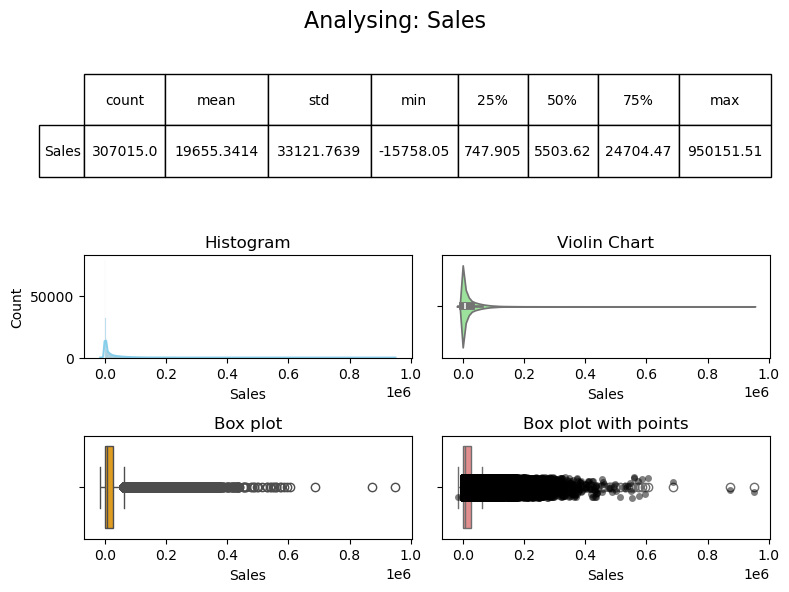

In [9]:
# Variable: Vendas
# Convert from string to float
df["Sales"] = df["Vendas"].str.replace(",", "").astype(float)

# Count total missing/invalid
missing_count = df["Sales"].isna().sum()
print(f"Total missing or errored rows: {missing_count}")

# Filter and display rows where the conversion failed
error_rows = df[df["Sales"].isna()]
print(error_rows[["Vendas", "Sales"]])

# Check the earliest and latest
print(df["Sales"].describe())

univariate_numeric_variable(df, "Sales")

#### <span style="color:green">Variable Sales_adj</span>

count    307015.000000
mean      19655.435832
std       33121.694370
min           0.000000
25%         747.905000
50%        5503.620000
75%       24704.470000
max      950151.510000
Name: Sales_adj, dtype: float64


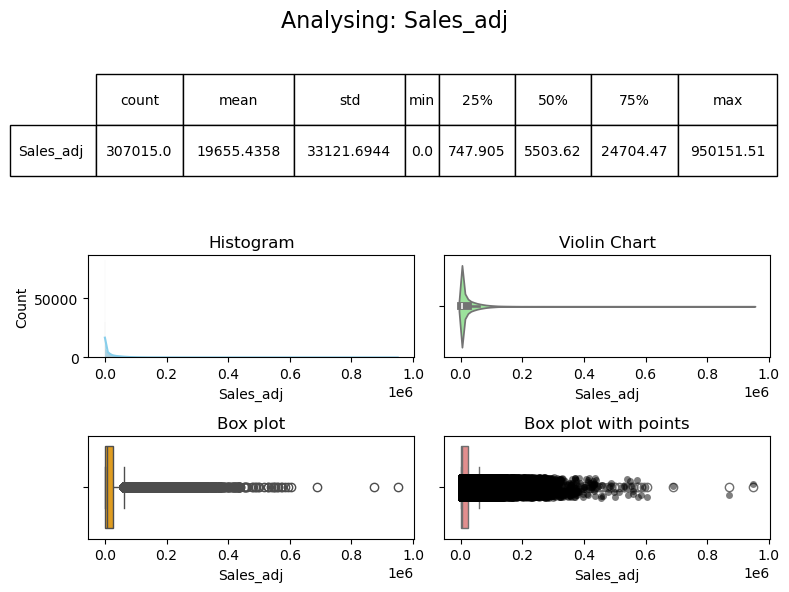

In [10]:
df["Sales_adj"] = df["Sales"].clip(lower=0)

# Check the earliest and latest
print(df["Sales_adj"].describe())

univariate_numeric_variable(df, "Sales_adj")

### <span style="color:green">Variable: Company</span>

- Decided to create a string for each company.
- Note that `Comp_1` is the one that appears the most in the database as `Comp_23` appears the least.

['Comp_1' 'Comp_2' 'Comp_5' 'Comp_15' 'Comp_16' 'Comp_6' 'Comp_13'
 'Comp_12' 'Comp_9' 'Comp_19' 'Comp_18' 'Comp_21' 'Comp_22' 'Comp_23']
Categorical variable describe:


,count,unique,top,freq
Company,307015,14,Comp_1,31095


Frequency table of categorical variable (with percentage and total):


,Company,Frequency,Percentage (%)
0,Comp_1,31095,10.13
1,Comp_9,29106,9.48
2,Comp_2,27960,9.11
3,Comp_19,26106,8.50
4,Comp_18,25373,8.26
5,Comp_15,24840,8.09
6,Comp_16,24746,8.06
7,Comp_5,24664,8.03
8,Comp_12,24512,7.98
9,Comp_13,22759,7.41


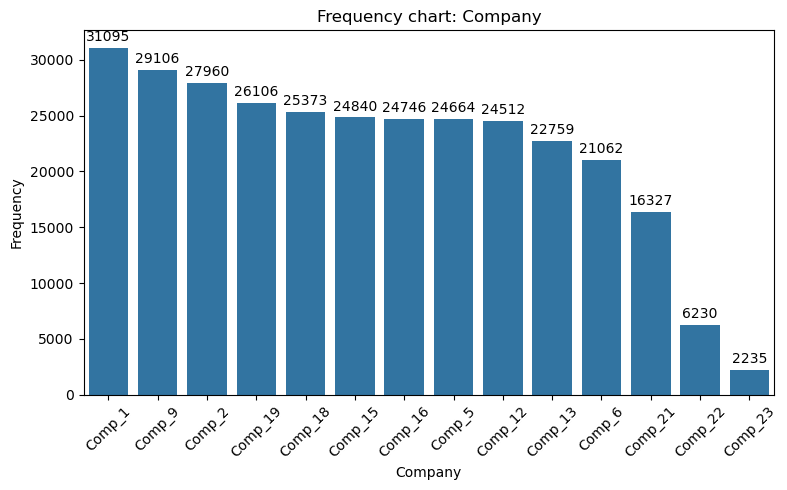

In [11]:
# Variable: Empresa
df["Company"] = "Comp_" + df["Empresa"].astype(str)

print(df["Company"].unique())

univariate_categorical_variable(df, "Company")

### <span style="color:green">Variable: Section</span>

- `Seção 23` is the most frequent one in the database (representing 5.8%).
- `Seção 29` is the least present on the databse with only 14 records.

Categorical variable describe:


,count,unique,top,freq
Seção,307015,29,Seção 23,17827


Frequency table of categorical variable (with percentage and total):


,Seção,Frequency,Percentage (%)
0,Seção 23,17827,5.81
1,Seção 26,12908,4.20
2,Seção 20,12908,4.20
3,Seção 16,12907,4.20
4,Seção 13,12906,4.20
5,Seção 3,12906,4.20
6,Seção 4,12906,4.20
7,Seção 17,12906,4.20
8,Seção 2,12906,4.20
9,Seção 9,12906,4.20


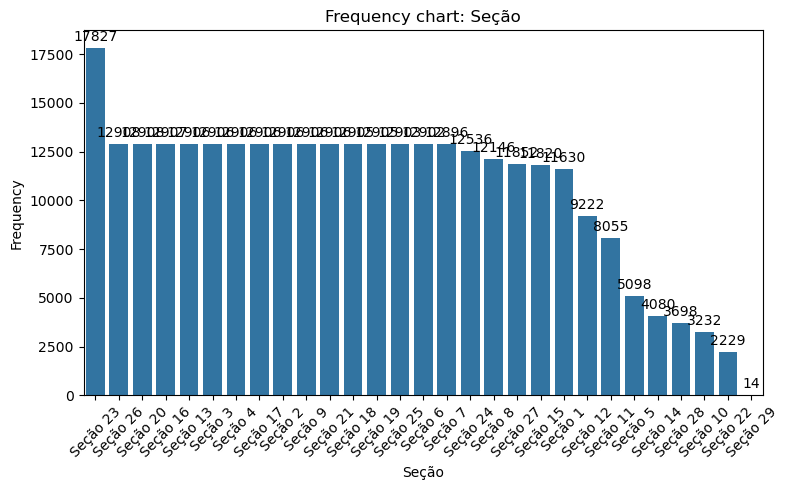

In [12]:
univariate_categorical_variable(df, "Seção")

### <span style="color:green">Variable: Department</span>

- `Depto 3`	is the most frequent, representing 38% of the data.
- `Depto 4` & `Depto 2` represent ~25% of the data
- All other departments are below 10%.


Categorical variable describe:


,count,unique,top,freq
Departamento,307015,7,Depto 3,117115


Frequency table of categorical variable (with percentage and total):


,Departamento,Frequency,Percentage (%)
0,Depto 3,117115,38.15
1,Depto 4,79294,25.83
2,Depto 2,77439,25.22
3,Depto 5,12903,4.20
4,Depto 1,11630,3.79
5,Depto 7,4936,1.61
6,Depto 6,3698,1.20
7,Total,307015,100.00


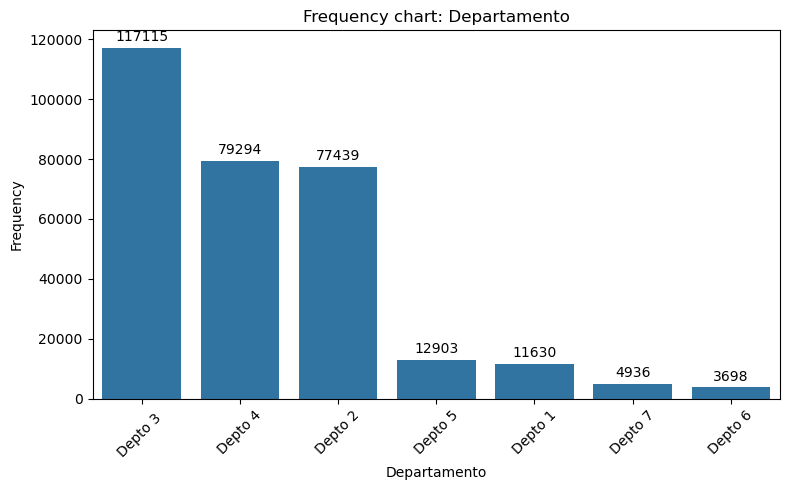

In [13]:
univariate_categorical_variable(df, "Departamento")

### <span style="color:purple">Variables Final Notes</span>

We have looked at each variable separatelly, but each level of combination can give us another directionality of how the data can be used to get the best prediction out of it.

- Company - Department - Section : 
    - Using this combination we can see that not all companies have the same department nor the same sections of number of sections. 
    - The number of days is also not the same.


- Department - Section : 
    - Using this combination we can see that not all departments have the same sections of number of sections.
    - The number of days is also not the same.

Since the initial problem told us to focus on Department 2 or 4, let's group our data athe Department level, and _ignore_ for now Company and Section variables as they seem to split the information too much and can cause noise when forecasting.

In [14]:
df.groupby(['Company', 'Departamento', 'Seção']).size()

Company  Departamento  Seção   
Comp_1   Depto 1       Seção 1     1139
         Depto 2       Seção 16    1139
                       Seção 17    1139
                       Seção 2     1139
                       Seção 26    1139
                                   ... 
Comp_9   Depto 4       Seção 23    1148
                       Seção 24    1148
         Depto 5       Seção 25    1148
         Depto 6       Seção 28     678
         Depto 7       Seção 23     360
Length: 394, dtype: int64

In [15]:
df.groupby(['Departamento', 'Seção']).size()

Departamento  Seção   
Depto 1       Seção 1     11630
Depto 2       Seção 16    12907
              Seção 17    12906
              Seção 2     12906
              Seção 26    12908
              Seção 3     12906
              Seção 4     12906
Depto 3       Seção 10     3232
              Seção 11     8055
              Seção 12     9222
              Seção 13    12906
              Seção 14     4080
              Seção 15    11820
              Seção 27    11852
              Seção 5      5098
              Seção 6     12902
              Seção 7     12896
              Seção 8     12146
              Seção 9     12906
Depto 4       Seção 18    12905
              Seção 19    12905
              Seção 20    12908
              Seção 21    12906
              Seção 22     2229
              Seção 23    12905
              Seção 24    12536
Depto 5       Seção 25    12903
Depto 6       Seção 28     3698
Depto 7       Seção 23     4922
              Seção 29       14
dtype: int64

## Group By Department


In [16]:
# aggregate by Department & Date
df_depts = df.groupby(["Departamento", "Date"]).agg({
    'Sales_adj': 'sum',           # Sum sales for the day
    'Feriado': 'max',         # Max flag (1 if any record is holiday, else 0)
    'Pagamento': 'max',
    'Vale': 'max'
}).reset_index()

Categorical variable describe:


,count,unique,top,freq
Departamento,7707,7,Depto 1,1148


Frequency table of categorical variable (with percentage and total):


,Departamento,Frequency,Percentage (%)
0,Depto 1,1148,14.90
1,Depto 2,1148,14.90
2,Depto 3,1148,14.90
3,Depto 4,1148,14.90
4,Depto 5,1148,14.90
5,Depto 7,1147,14.88
6,Depto 6,820,10.64
7,Total,7707,100.00


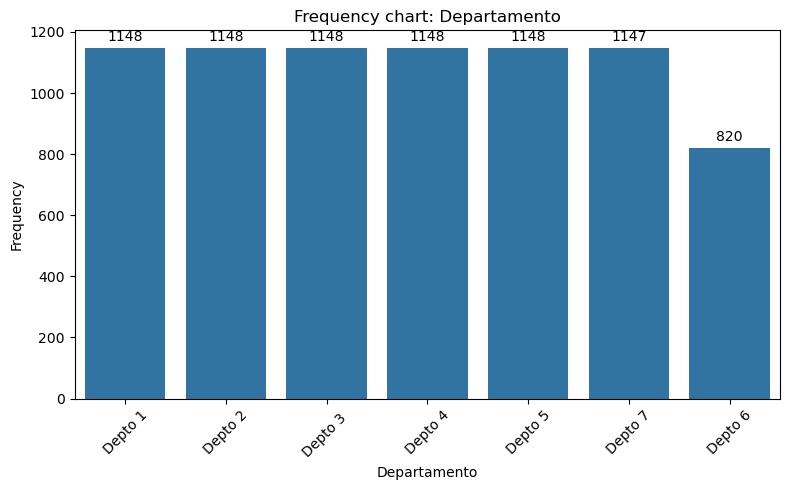

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
Feriado,7707.0,0.036331,0.187124,0.0,0.0,0.0,0.0,1.0


Frequency table of categorical variable (with percentage and total):


,Feriado,Frequency,Percentage (%)
0,0,7427,96.37
1,1,280,3.63
2,Total,7707,100.00


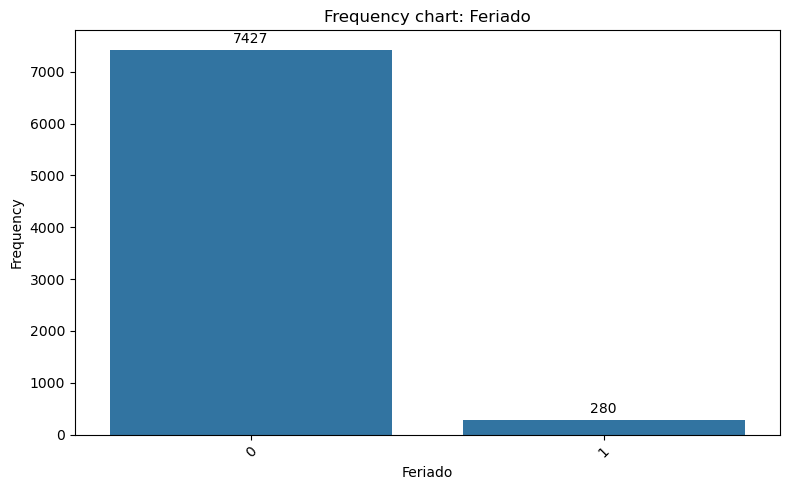

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
Pagamento,7707.0,0.034903,0.183547,0.0,0.0,0.0,0.0,1.0


Frequency table of categorical variable (with percentage and total):


,Pagamento,Frequency,Percentage (%)
0,0,7438,96.51
1,1,269,3.49
2,Total,7707,100.00


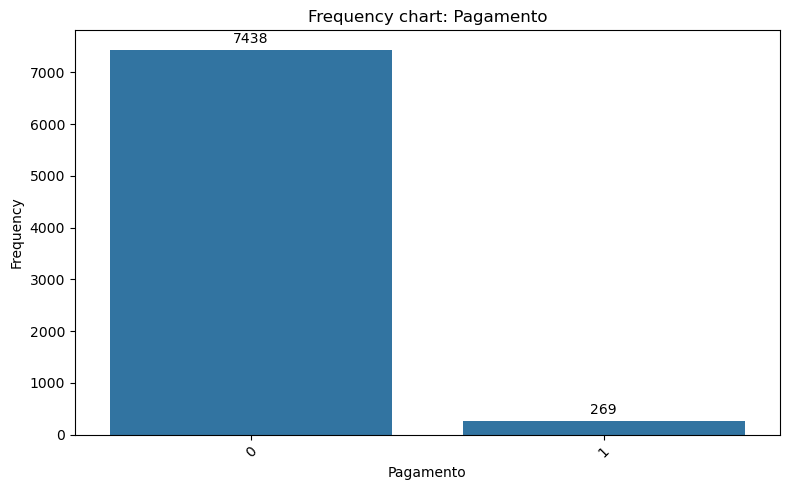

Categorical variable describe:


,count,mean,std,min,25%,50%,75%,max
Vale,7707.0,0.040223,0.196495,0.0,0.0,0.0,0.0,1.0


Frequency table of categorical variable (with percentage and total):


,Vale,Frequency,Percentage (%)
0,0,7397,95.98
1,1,310,4.02
2,Total,7707,100.00


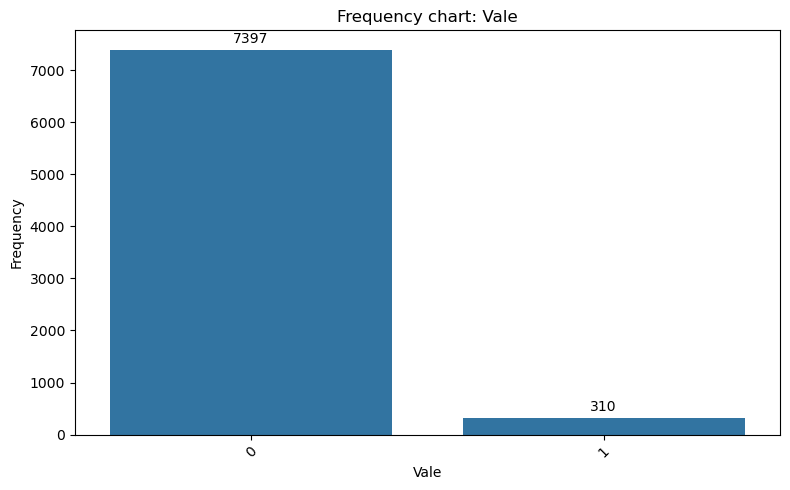

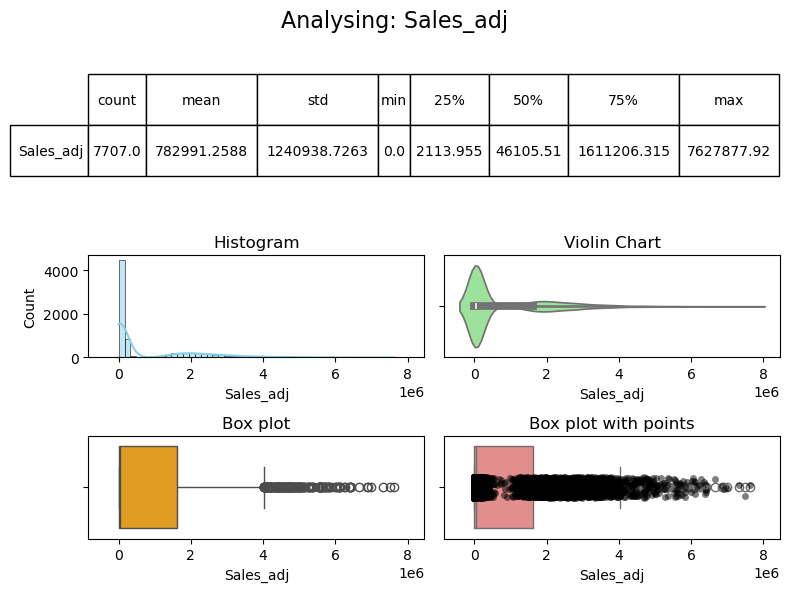

In [17]:
univariate_categorical_variable(df_depts, "Departamento")

univariate_categorical_variable(df_depts, "Feriado")

univariate_categorical_variable(df_depts, "Pagamento")

univariate_categorical_variable(df_depts, "Vale")

univariate_numeric_variable(df_depts, "Sales_adj")

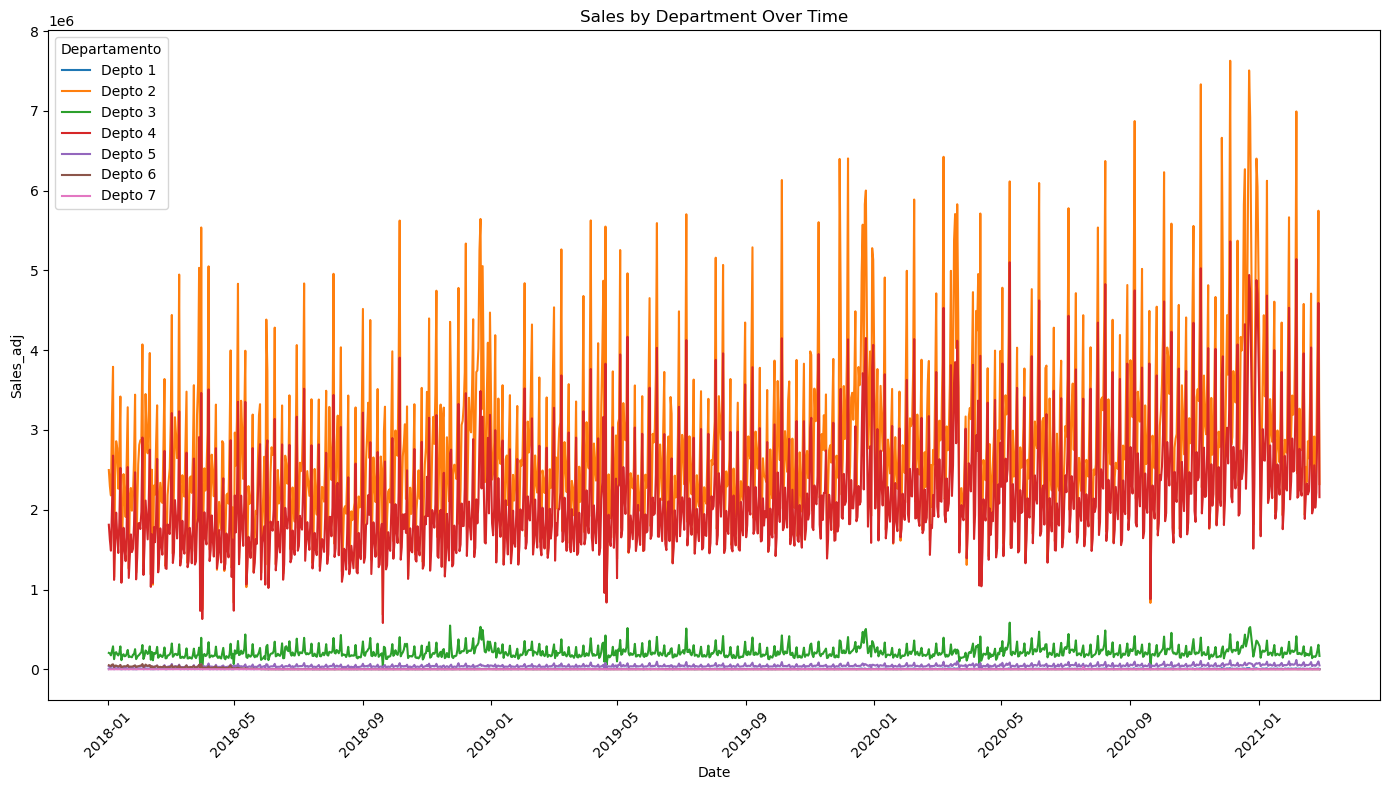

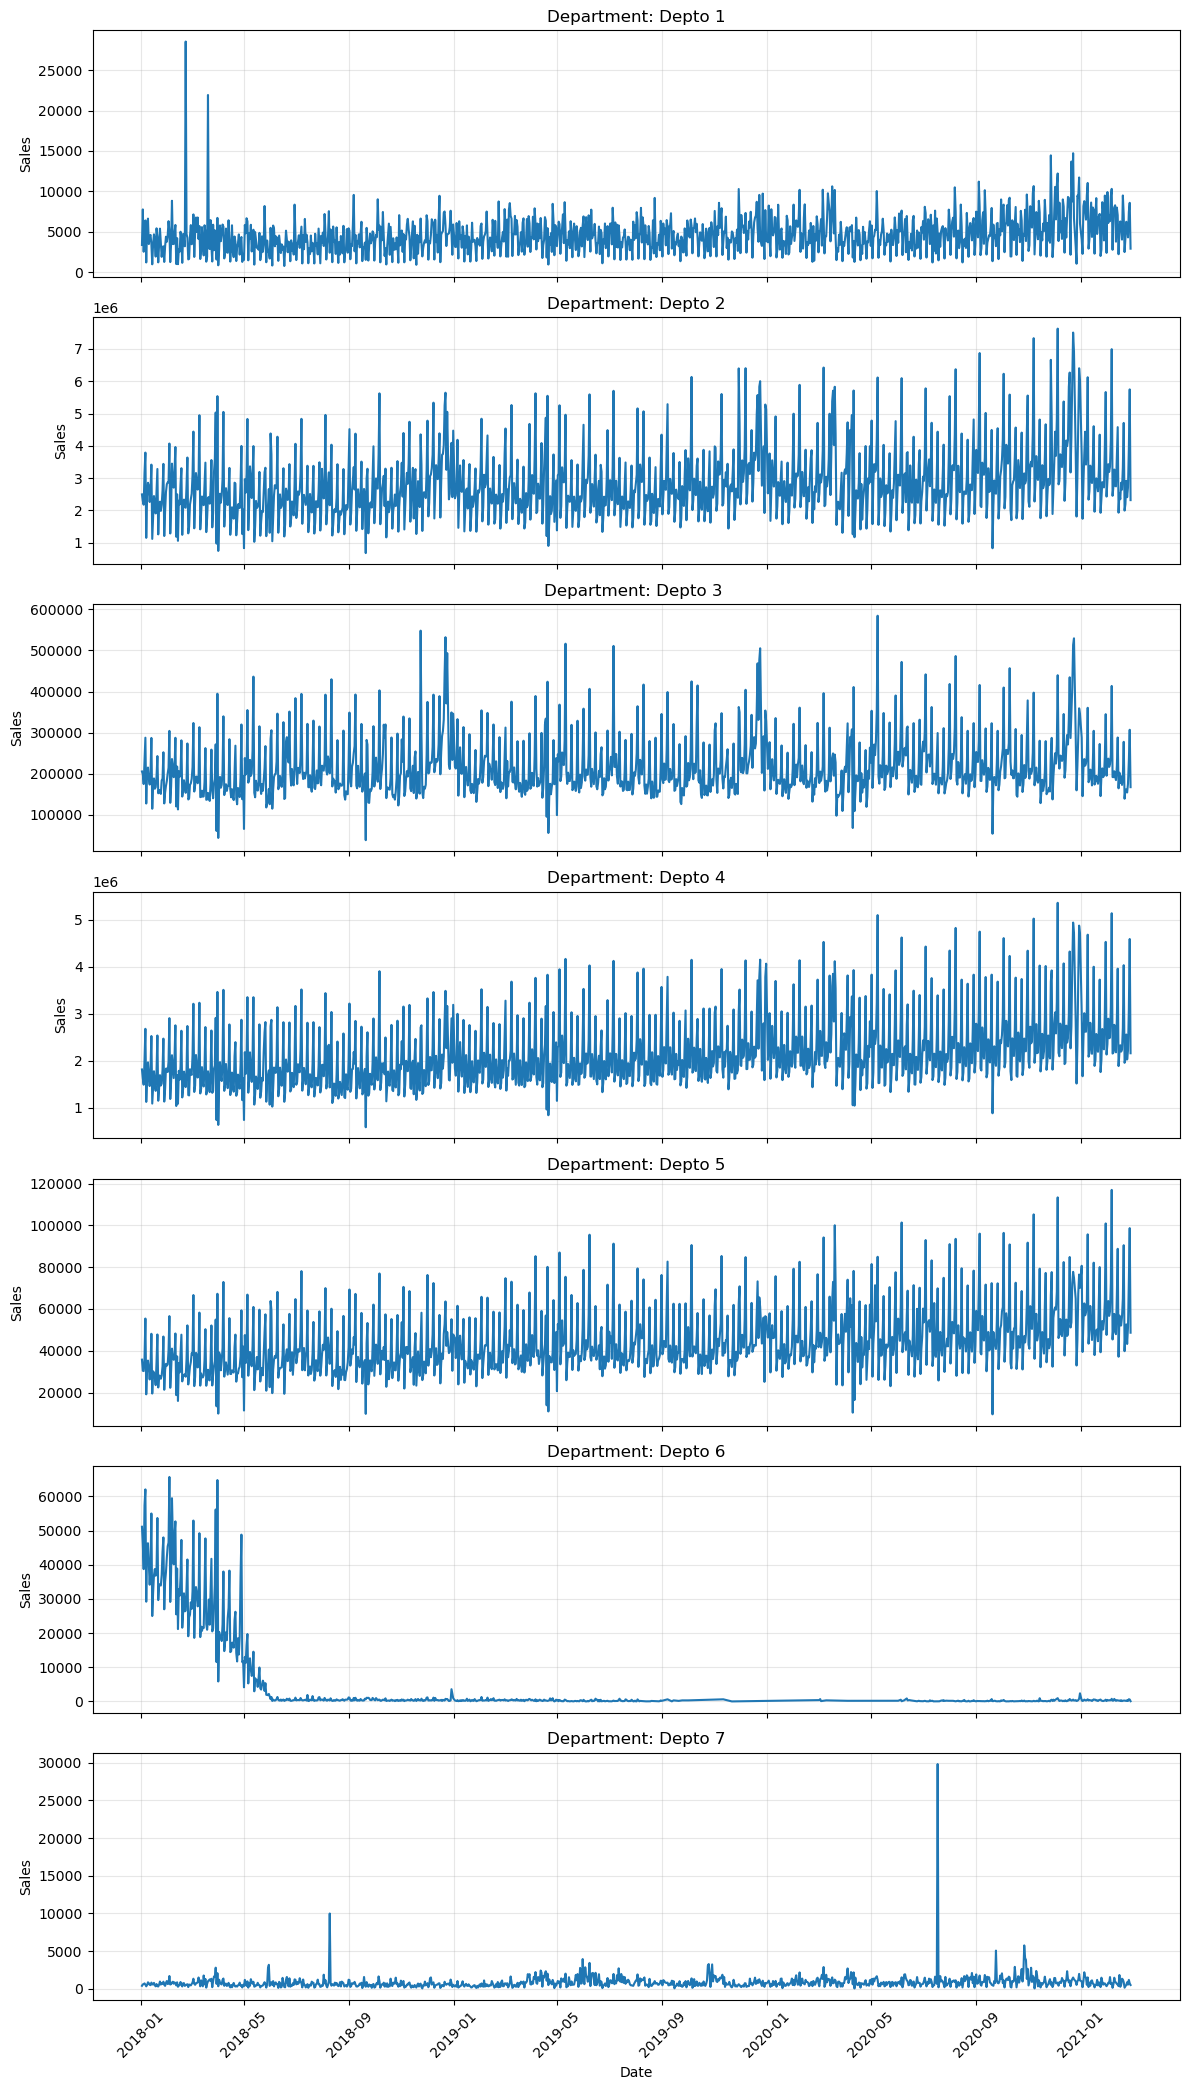

In [18]:
# plot Department & Sales by Date

plt.figure(figsize=(14, 8))
sns.lineplot(data=df_depts, x='Date', y='Sales_adj', hue='Departamento')
plt.title('Sales by Department Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(nrows=len(df_depts['Departamento'].unique()), 
                         figsize=(12, 3*len(df_depts['Departamento'].unique())), 
                         sharex=True)

for ax, (dept, group) in zip(axes, df_depts.groupby('Departamento')):
    ax.plot(group['Date'], group['Sales_adj'], linestyle='-')
    ax.set_title(f'Department: {dept}')
    ax.set_ylabel('Sales')
    ax.grid(True, alpha=0.3)

plt.xlabel('Date')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Choose Department and Processing

From this moment, we have aggregated Department by dates, and we will now choose a department to focus on.

There is no more Company or Section.

In [19]:
# choosing department
choose_dept = 'Depto 4'
print(f"We will be working with: {choose_dept}")

df_dep = df_depts[df_depts['Departamento'] == choose_dept].copy()

We will be working with: Depto 4


### Input missing dates

We need to create a dataset with all the dates for the period we are going to analyze.

- Notes:
    - Every missing date was new year and christmas!
        - This might mean that there were never sales on this dates possibly because they don't open?
        - We can create a flag to indicate that there will never be sales that day for the future.
    

In [106]:
# get minimum year
min_year = df_dep['Date'].dt.year.min()

# create start date as Jan 1st of that year
start_date = pd.Timestamp(f'{min_year}-01-01')

# get the end date
end_date = df_dep['Date'].max() 

# create complete date range
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')

# get unique departments
departments = df_dep['Departamento'].unique()

# create all combinations of dates and departments
df_complete = pd.DataFrame(
    [(date, dept) for date in all_dates for dept in departments],
    columns=['Date', 'Departamento']
)

# merge with original data
df_complete = df_complete.merge(df_dep, on=['Date', 'Departamento'], how='left')



In [107]:
# Analysis on missing dates
df_complete[df_complete["Feriado"].isna()]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale
0,2018-01-01,Depto 4,NaN,NaN,NaN,NaN
358,2018-12-25,Depto 4,NaN,NaN,NaN,NaN
365,2019-01-01,Depto 4,NaN,NaN,NaN,NaN
723,2019-12-25,Depto 4,NaN,NaN,NaN,NaN
730,2020-01-01,Depto 4,NaN,NaN,NaN,NaN
1089,2020-12-25,Depto 4,NaN,NaN,NaN,NaN
1096,2021-01-01,Depto 4,NaN,NaN,NaN,NaN


### Variable: isClosed

- Happens on every Dec-25 and Jan-01

In [22]:
df_complete['isClosed'] = ((df_complete['Date'].dt.month == 12) & (df_complete['Date'].dt.day == 25)) | \
                          ((df_complete['Date'].dt.month == 1) & (df_complete['Date'].dt.day == 1))

df_complete['isClosed'] = df_complete['isClosed'].astype(int) 

### Variable: Feriado

#### <span style="color:purple">External Dataset:</span> `holidays.csv`

We got Brazilian holidays through API [Feriados API](https://feriadosapi.com/docs#introducao). 
This was chosen to make it easier to map the flag on future dates.

We will be checking which holidays are map which are not and how to use this for future dates.




Learnings:
- 

Dictionary


| #   | Variable    | Description                                                                                                                  | Type                  | Raw | Notes |
| --- | ----------- | ---------------------------------------------------------------------------------------------------------------------------- | --------------------- | --- | ----- |
| 1   | id          | unique ID of holiday date                                                                                                    | Qualitative Nominal   | Y   |       |
| 2   | data        | Holiday date, format `DD/MM/YYYY`                                                                                            | Date                  | Y   |       |
| 3   | nome        | Holiday name                                                                                                                 | Qualitative Nominal   | Y   |       |
| 4   | tipo        | Which holiday databse the holiday was extracted: National / State / State Capital<br>`NACIONAL` /  `ESTADUAL` /  `MUNICIPAL` | Qualitative Nominal   | Y   |       |
| 5   | descricao   | Holiday descriptive long                                                                                                     | Qualitative Nominal   | Y   |       |
| 6   | uf          | Brazilian State. <br>Only present in **tipo** = `ESTADUAL` /  `MUNICIPAL`                                                    | Qualitative Nominal   | Y   |       |
| 7   | codigo_ibge | City code according to IBGE.<br>Only present in **tipo** =  `MUNICIPAL`<br>                                                  | Qualitative Nominal   | Y   |       |
| 8   | bancario    | Flag for a bank holiday                                                                                                      | Qualitative Binary    | Y   |       |
| 9   | year        | Holiday date year extracted.                                                                                                 | Quantitative Discrete | Y   |       |
| 10  | type        | same as `tipo`<br>`national` /  `state` /  `capital`                                                                         | Qualitative Nominal   | Y   |       |
| 11  | state       | same as `uf`                                                                                                                 | Qualitative Nominal   | Y   |       |
| 12  | ibge_code   | same as `codigo_ibge`                                                                                                        | Qualitative Nominal   | Y   |       |
| 13  | Date        | Convert from a regular english date format `YYYY-MM-DD`                                                                      | Date                  | N   |       |




In [130]:
df_holiday["Date"] = pd.to_datetime(df_holiday["data"], format='%d/%m/%Y', errors='coerce')
# df_holiday.head()
# df_holiday[df_holiday["Date"] == '2019-10-12']

df_holiday_simple = df_holiday[["Date", "nome"]].copy()
df_holiday_unique = df_holiday_simple.drop_duplicates(subset=['Date'], keep='first')

# df_holiday_simpleSP = df_holiday_simple[df_holiday_simple["state"] == 'SP'].copy()
# df_holiday_simpleSP.head()

# Check if there are any duplicate dates
has_duplicates = df_holiday_unique['Date'].duplicated().any()
print(f"Are there duplicate dates? {has_duplicates}")

# See which dates are duplicated
duplicate_dates = df_holiday_unique[df_holiday_unique['Date'].duplicated(keep=False)]
print("Duplicate dates:")
print(duplicate_dates['Date'].value_counts())



Are there duplicate dates? False
Duplicate dates:
Series([], Name: count, dtype: int64)


In [133]:
df_complete1 = df_complete.merge(df_holiday_unique, on=['Date'], how='left')

In [134]:
df_map_holidays = df_complete1[df_complete1["Feriado"] == 1]

print(f"Total holidays in the database: {df_map_holidays.shape}")
print(f"Holidays missing description: {df_map_holidays[df_map_holidays["nome"].isna()].shape}")

Total holidays in the database: (43, 7)
Holidays missing description: (0, 7)


In [135]:
df_map_holidays[df_map_holidays["nome"].isna()]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,nome


In [136]:
df_map_holidays.groupby(['nome']).size()

nome
Aniversário da Cidade de São Paulo              4
Carnaval                                        4
Carnaval (Segunda-feira)                        4
Corpus Christi                                  3
Dia Mundial do Trabalho                         3
Dia Nacional de Zumbi e da Consciência Negra    2
Dia da Consciência Negra                        1
Dia de Finados                                  2
Dia de Tiradentes                               3
Finados                                         1
Imaculada Conceição                             3
Independência do Brasil                         3
Nossa Senhora Aparecida                         3
Proc. República Rio Grandense                   1
Proclamação da República                        3
Sexta-Feira Santa                               1
Sexta-feira Santa                               2
dtype: int64

In [129]:
df_map_holidays[df_map_holidays['nome'] == "Sexta-feira Santa"]

,Date,Departamento,Sales_adj,Feriado,Pagamento,Vale,nome
95,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
96,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
97,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
98,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
99,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
100,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
101,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
102,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
103,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa
104,2018-03-30,Depto 4,732475.63,1.0,0.0,0.0,Sexta-feira Santa


## Business Understanding: Variable Analysis

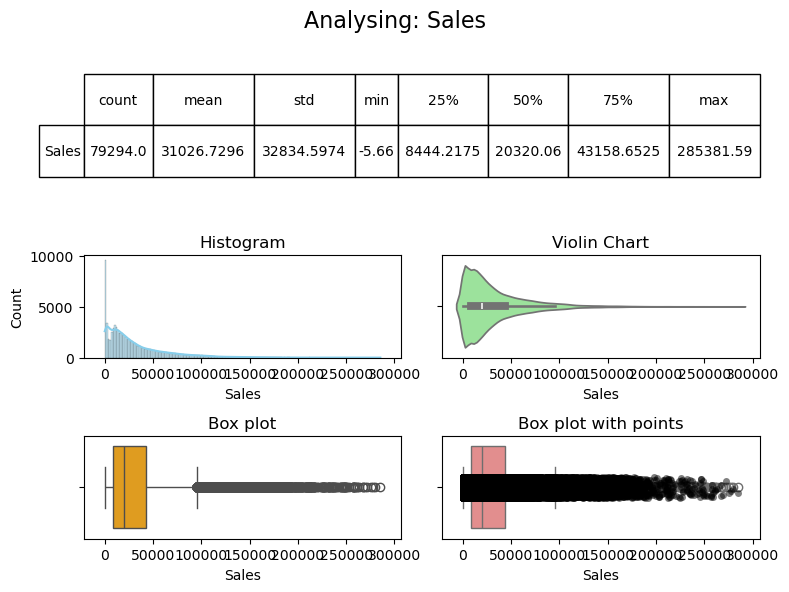

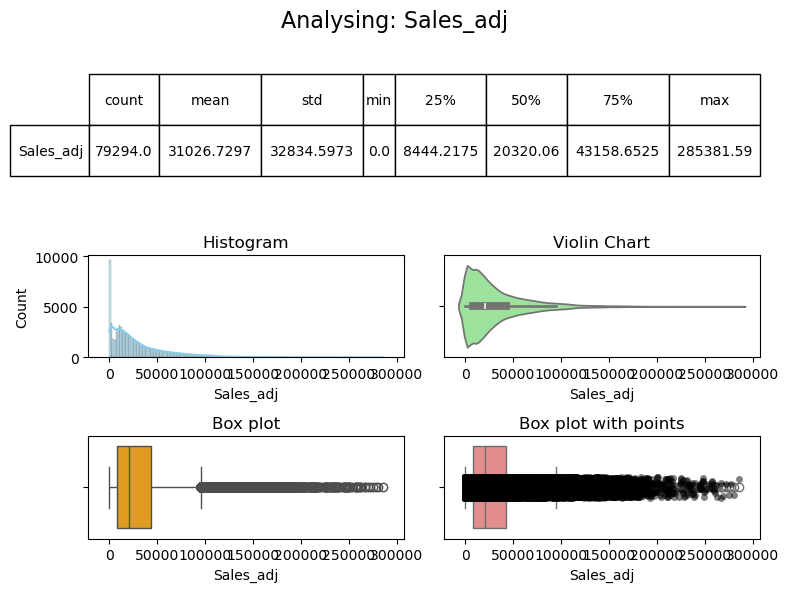

Categorical variable describe:


,count,unique,top,freq
Company,79294,14,Comp_1,7961


Frequency table of categorical variable (with percentage and total):


,Company,Frequency,Percentage (%)
0,Comp_1,7961,10.04
1,Comp_9,7817,9.86
2,Comp_2,6995,8.82
3,Comp_12,6887,8.69
4,Comp_5,6699,8.45
5,Comp_13,6692,8.44
6,Comp_19,6660,8.40
7,Comp_16,5852,7.38
8,Comp_15,5845,7.37
9,Comp_18,5843,7.37


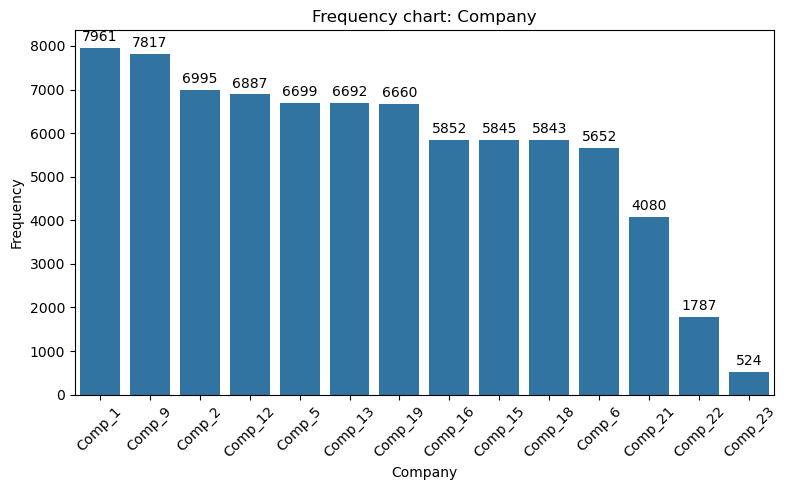

Categorical variable describe:


,count,unique,top,freq
Seção,79294,7,Seção 20,12908


Frequency table of categorical variable (with percentage and total):


,Seção,Frequency,Percentage (%)
0,Seção 20,12908,16.28
1,Seção 21,12906,16.28
2,Seção 18,12905,16.27
3,Seção 19,12905,16.27
4,Seção 23,12905,16.27
5,Seção 24,12536,15.81
6,Seção 22,2229,2.81
7,Total,79294,100.00


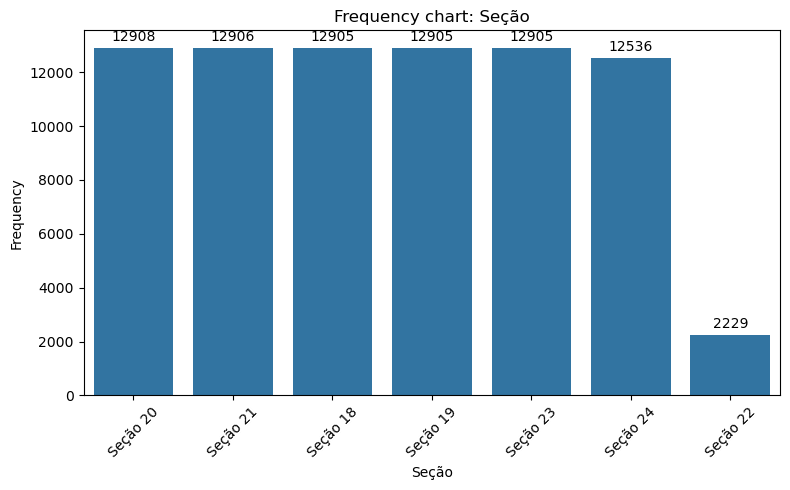

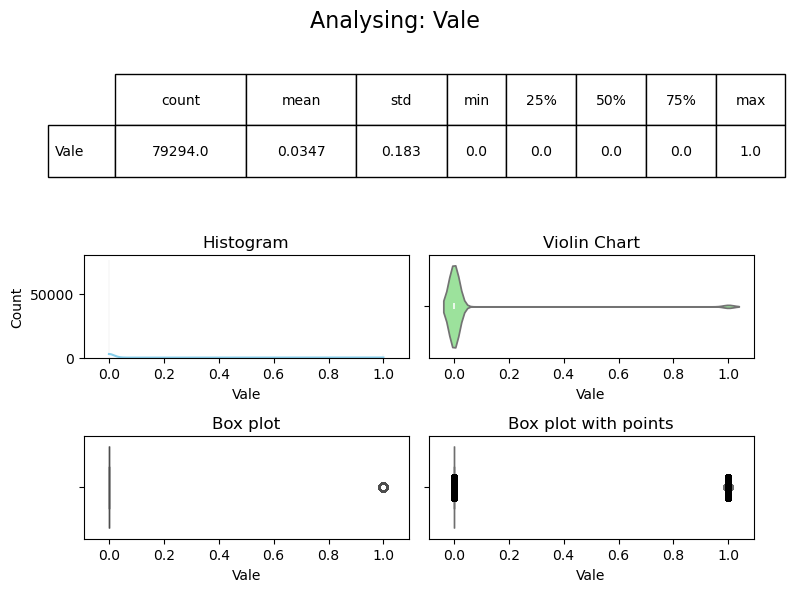

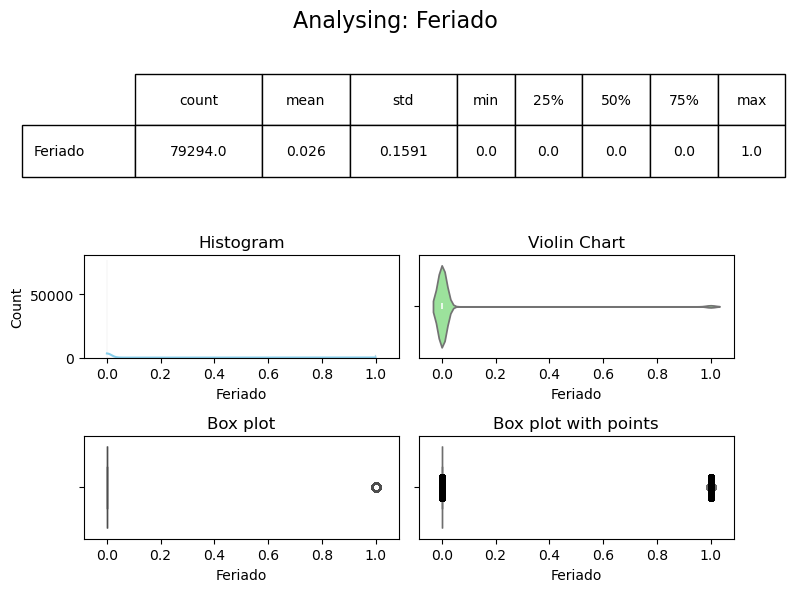

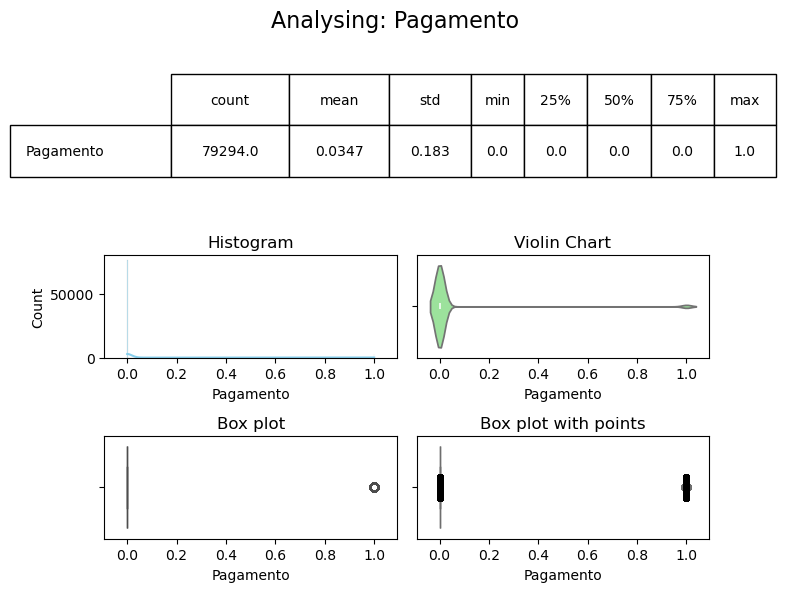

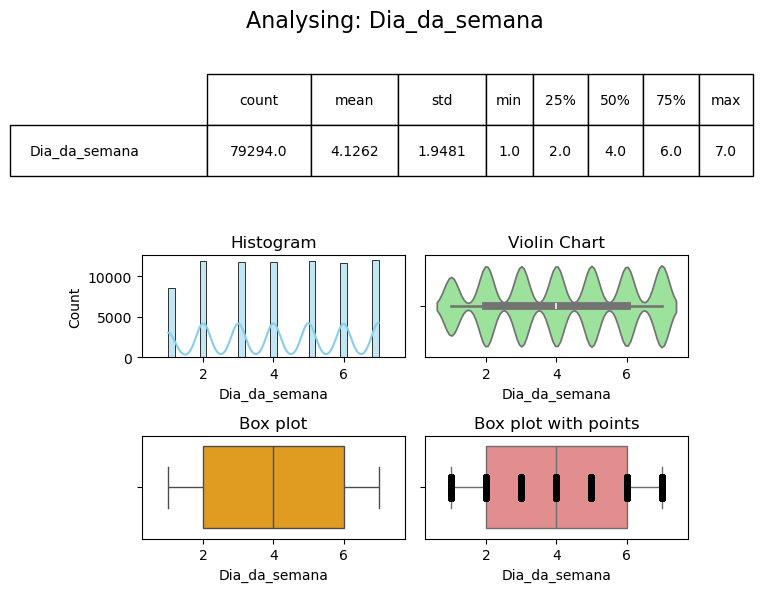

In [ ]:
# univariate analysis
univariate_numeric_variable(df_dep, "Sales")

univariate_numeric_variable(df_dep, "Sales_adj")

univariate_categorical_variable(df_dep, "Company")

univariate_categorical_variable(df_dep, "Seção")

univariate_numeric_variable(df_dep, "Vale")

univariate_numeric_variable(df_dep, "Feriado")

univariate_numeric_variable(df_dep, "Pagamento")

univariate_numeric_variable(df_dep, "Dia_da_semana")

## Data Visualization: Understanding the Business Context

        Date       Sales  Feriado  Pagamento  Vale
0 2018-01-02  1812134.19        0          0     0
1 2018-01-03  1622115.60        0          0     0
2 2018-01-04  1486888.42        0          0     0
3 2018-01-05  2015469.36        0          1     0
4 2018-01-06  2678387.64        0          0     0


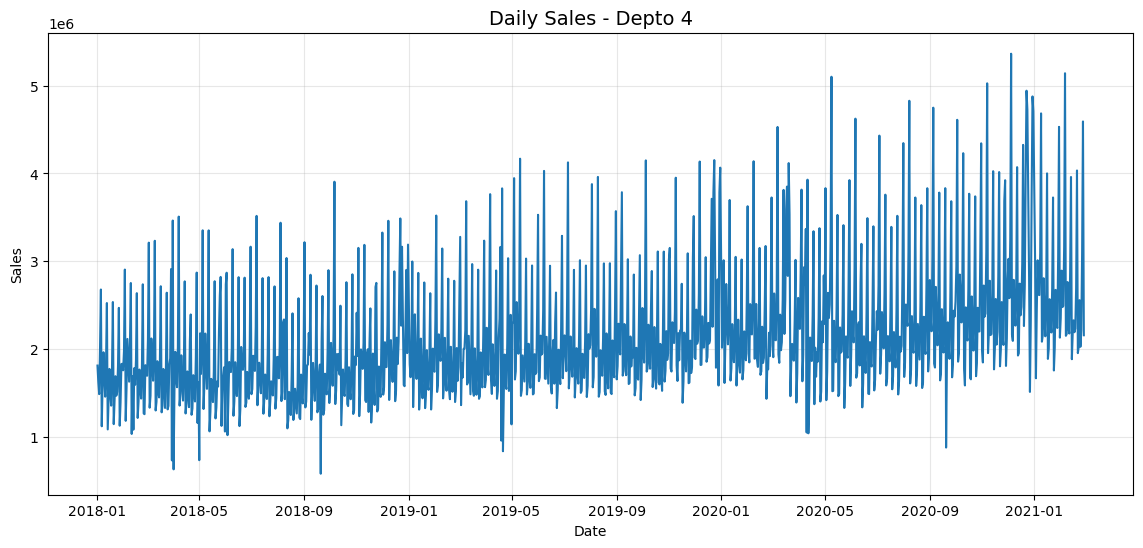

In [14]:
# aggregate by date
df_daily = df_dep.groupby("Date").agg({
    'Sales': 'sum',           # Sum sales for the day
    'Feriado': 'max',         # Max flag (1 if any record is holiday, else 0)
    'Pagamento': 'max',
    'Vale': 'max'
}).reset_index()

# Display result
print(df_daily.head())

# Time series plot of the target variable
plt.figure(figsize=(14, 6))
plt.plot(df_daily['Date'], df_daily['Sales'])
plt.title(f'Daily Sales - {choose_dept}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

Date range: 2018-01-02 00:00:00 to 2021-02-28 00:00:00
Total days in range: 1154
Actual rows: 1148
Missing days: 6
        Date       Sales  Feriado  Pagamento  Vale
0 2018-01-02  1812134.19      0.0        0.0   0.0
1 2018-01-03  1622115.60      0.0        0.0   0.0
2 2018-01-04  1486888.42      0.0        0.0   0.0
3 2018-01-05  2015469.36      0.0        1.0   0.0
4 2018-01-06  2678387.64      0.0        0.0   0.0
Total rows after filling: 1154


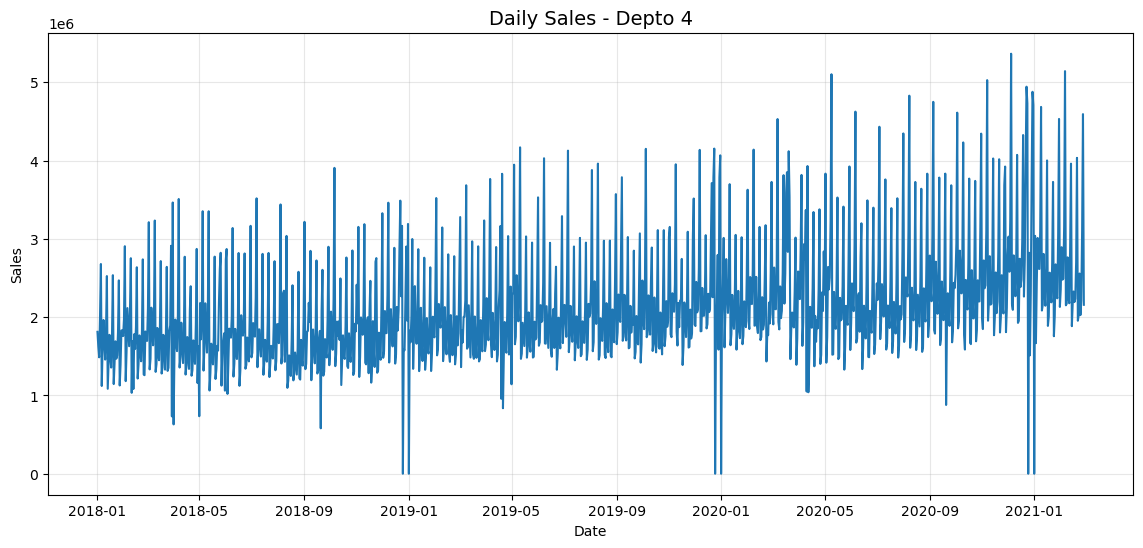

In [15]:
# Check if we have all dates in your range
print(f"Date range: {df_daily['Date'].min()} to {df_daily['Date'].max()}")
print(f"Total days in range: {(df_daily['Date'].max() - df_daily['Date'].min()).days + 1}")
print(f"Actual rows: {len(df_daily)}")
print(f"Missing days: {((df_daily['Date'].max() - df_daily['Date'].min()).days + 1) - len(df_daily)}")

# create complete date range
date_range = pd.date_range(
    start=df_daily['Date'].min(), 
    end=df_daily['Date'].max(),
    freq='D'  # Daily frequency
)

# reindex to include all dates
df_complete = df_daily.set_index('Date').reindex(date_range).reset_index()
df_complete.rename(columns={'index': 'Date'}, inplace=True)

# fill missing values
df_complete['Sales'] = df_complete['Sales'].fillna(0.000001)  # Or use other methods
df_complete['Feriado'] = df_complete['Feriado'].fillna(0)     # Default to not holiday
df_complete['Pagamento'] = df_complete['Pagamento'].fillna(0)
df_complete['Vale'] = df_complete['Vale'].fillna(0)

print(df_complete.head())
print(f"Total rows after filling: {len(df_complete)}")

# Time series plot of the target variable
plt.figure(figsize=(14, 6))
plt.plot(df_complete['Date'], df_complete['Sales'])
plt.title(f'Daily Sales - {choose_dept}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()


# Time Series Analysis - Step A: Visual Analysis



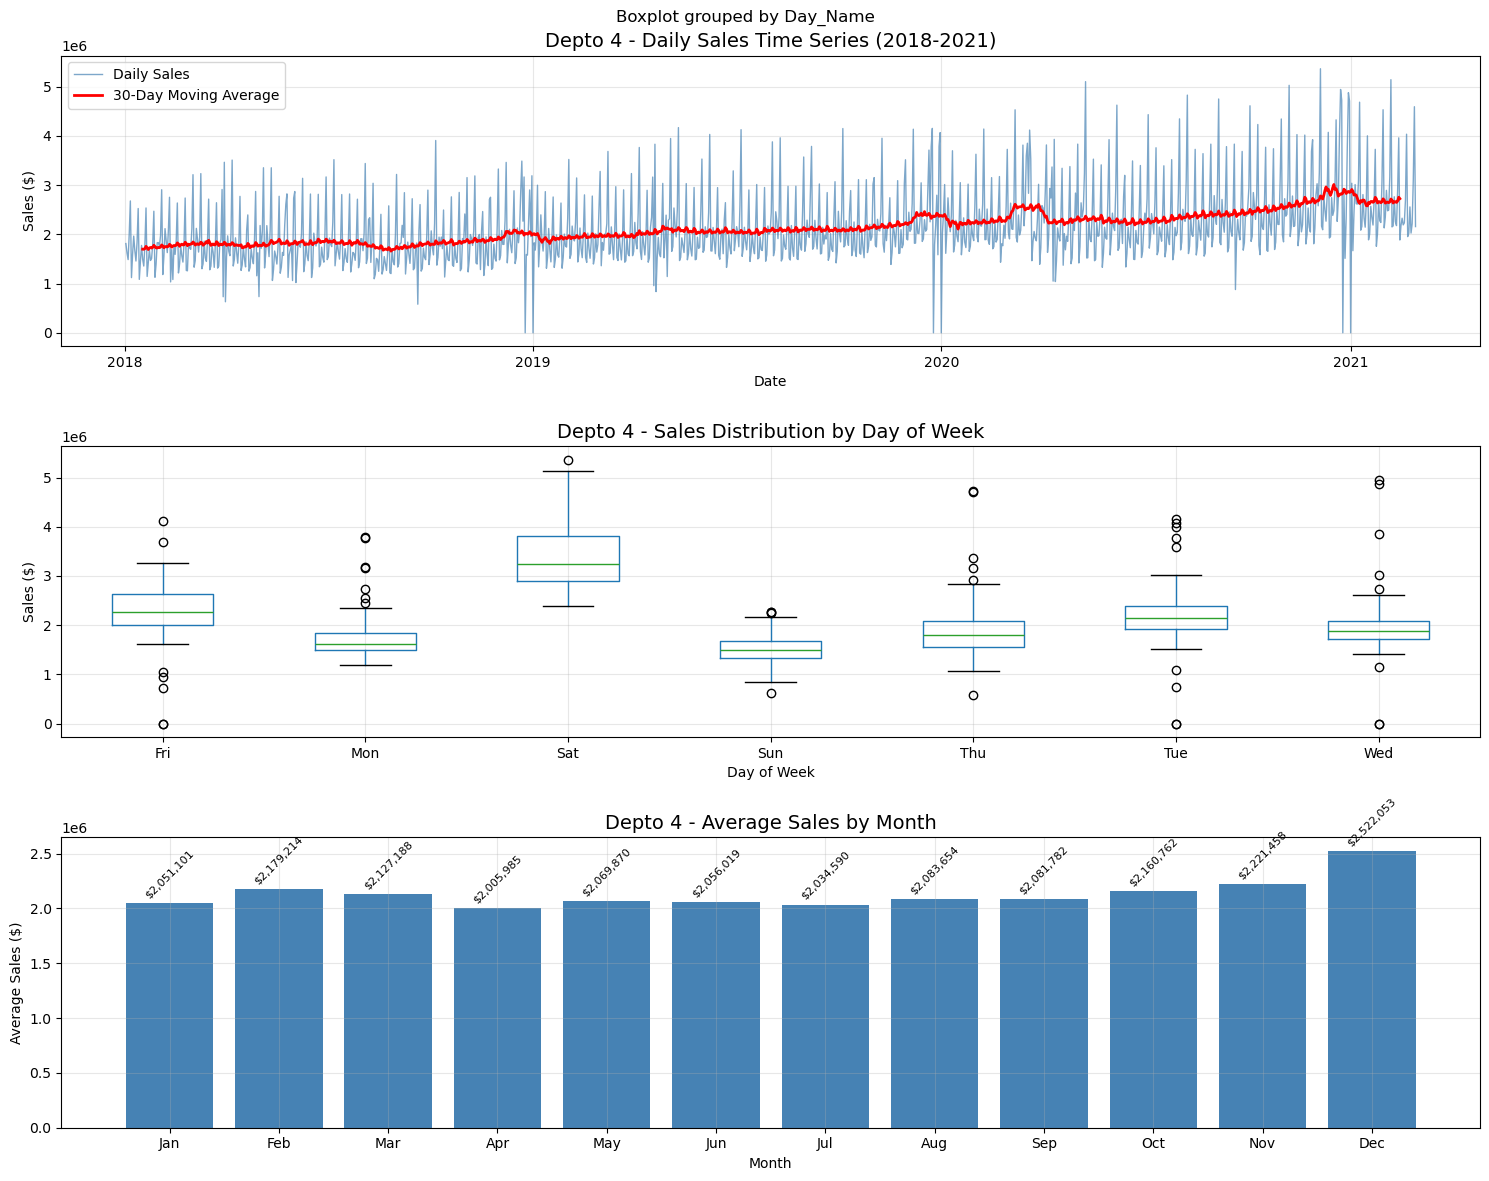

In [18]:
# Prepare the time series data
# Use the complete daily data we created earlier
ts = df_complete.set_index('Date')['Sales']

# Create time series plot with trend line
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Plot 1: Full time series with trend
axes[0].plot(ts.index, ts.values, linewidth=1.0, alpha=0.7, color='steelblue', label='Daily Sales')
# Add trend line using moving average (30-day)
ts_ma = ts.rolling(window=30, center=True).mean()
axes[0].plot(ts_ma.index, ts_ma.values, linewidth=2, color='red', label='30-Day Moving Average')
axes[0].set_title(f'{choose_dept} - Daily Sales Time Series (2018-2021)', fontsize=14)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Sales ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Format x-axis
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].xaxis.set_major_locator(mdates.YearLocator())

# Plot 2: Box plot by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
# Add day of week to dataframe
df_complete['Day_of_Week'] = df_complete['Date'].dt.dayofweek + 1  # Monday=1
df_complete['Day_Name'] = df_complete['Day_of_Week'].map(lambda x: day_names[x-1])

# Box plot
df_complete.boxplot(column='Sales', by='Day_Name', ax=axes[1])
axes[1].set_title(f'{choose_dept} - Sales Distribution by Day of Week', fontsize=14)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Sales ($)')
axes[1].grid(True, alpha=0.3)

# Plot 3: Monthly averages
monthly_avg = df_complete.groupby(df_complete['Date'].dt.month)['Sales'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[2].bar(month_names, monthly_avg.values, color='steelblue')
axes[2].set_title(f'{choose_dept} - Average Sales by Month', fontsize=14)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Sales ($)')
axes[2].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(monthly_avg.values):
    axes[2].text(i, v + max(monthly_avg.values)*0.01, f'${v:,.0f}', 
                 ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

## Seasonal Subseries Plot

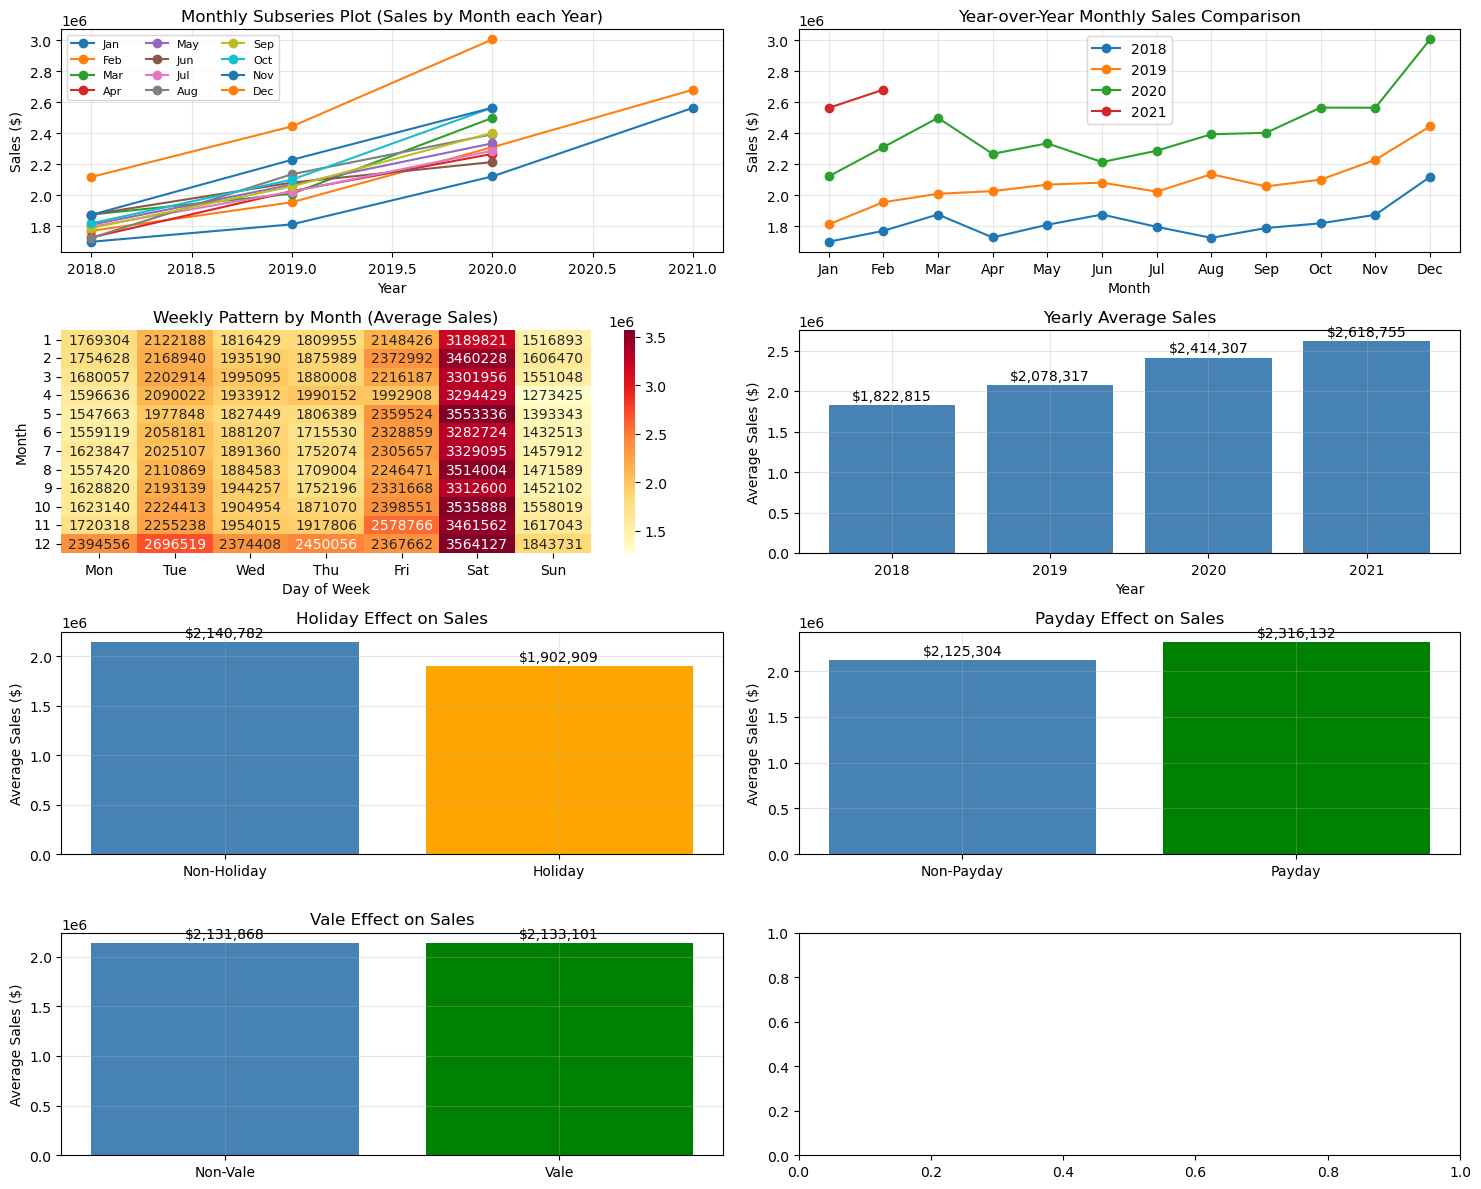

In [24]:
# Seasonal subseries plot - Monthly patterns
fig, axes = plt.subplots(4, 2, figsize=(15, 12))

# Prepare data for subseries plot
df_complete['Year'] = df_complete['Date'].dt.year
df_complete['Month'] = df_complete['Date'].dt.month

# Create subseries plot - using pivot_table to handle duplicates
monthly_data = df_complete.pivot_table(index='Year', columns='Month', values='Sales', aggfunc='mean')
monthly_data.columns = month_names

# Plot 1: Monthly subseries plot
for month in month_names:
    axes[0, 0].plot(monthly_data.index, monthly_data[month].values, 
                    marker='o', label=month, linewidth=1.5)
axes[0, 0].set_title('Monthly Subseries Plot (Sales by Month each Year)', fontsize=12)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Sales ($)')
axes[0, 0].legend(loc='best', ncol=3, fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Year-over-year comparison
for year in monthly_data.index:
    axes[0, 1].plot(month_names, monthly_data.loc[year].values, 
                    marker='o', label=str(year), linewidth=1.5)
axes[0, 1].set_title('Year-over-Year Monthly Sales Comparison', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Sales ($)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Weekly seasonality heatmap
# Create day of week patterns by month
weekly_pattern = df_complete.pivot_table(index='Month', columns='Day_Name', values='Sales', aggfunc='mean')
# Ensure all days are present
all_days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for day in all_days:
    if day not in weekly_pattern.columns:
        weekly_pattern[day] = 0
weekly_pattern = weekly_pattern[all_days]  # Reorder columns

sns.heatmap(weekly_pattern, ax=axes[1, 0], cmap='YlOrRd', annot=True, fmt='.0f')
axes[1, 0].set_title('Weekly Pattern by Month (Average Sales)', fontsize=12)
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Month')

# Plot 4: Yearly comparison
yearly_avg = df_complete.groupby(df_complete['Date'].dt.year)['Sales'].mean()
axes[1, 1].bar(yearly_avg.index.astype(str), yearly_avg.values, color='steelblue')
axes[1, 1].set_title('Yearly Average Sales', fontsize=12)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Sales ($)')
axes[1, 1].grid(True, alpha=0.3)

# Add value labels
for i, v in enumerate(yearly_avg.values):
    axes[1, 1].text(i, v + max(yearly_avg.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 5: Holiday effect
holiday_effect = df_complete.groupby('Feriado')['Sales'].mean()
axes[2, 0].bar(['Non-Holiday', 'Holiday'], holiday_effect.values, 
               color=['steelblue', 'orange'])
axes[2, 0].set_title('Holiday Effect on Sales', fontsize=12)
axes[2, 0].set_ylabel('Average Sales ($)')
axes[2, 0].grid(True, alpha=0.3)
for i, v in enumerate(holiday_effect.values):
    axes[2, 0].text(i, v + max(holiday_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 6: Payday effect
payday_effect = df_complete.groupby('Pagamento')['Sales'].mean()
axes[2, 1].bar(['Non-Payday', 'Payday'], payday_effect.values, 
               color=['steelblue', 'green'])
axes[2, 1].set_title('Payday Effect on Sales', fontsize=12)
axes[2, 1].set_ylabel('Average Sales ($)')
axes[2, 1].grid(True, alpha=0.3)
for i, v in enumerate(payday_effect.values):
    axes[2, 1].text(i, v + max(payday_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')

# Plot 7: Vale effect
vale_effect = df_complete.groupby('Vale')['Sales'].mean()
axes[3, 0].bar(['Non-Vale', 'Vale'], vale_effect.values, 
               color=['steelblue', 'green'])
axes[3, 0].set_title('Vale Effect on Sales', fontsize=12)
axes[3, 0].set_ylabel('Average Sales ($)')
axes[3, 0].grid(True, alpha=0.3)
for i, v in enumerate(vale_effect.values):
    axes[3, 0].text(i, v + max(vale_effect.values)*0.01, f'${v:,.0f}', 
                    ha='center', va='bottom')



plt.tight_layout()
plt.show()

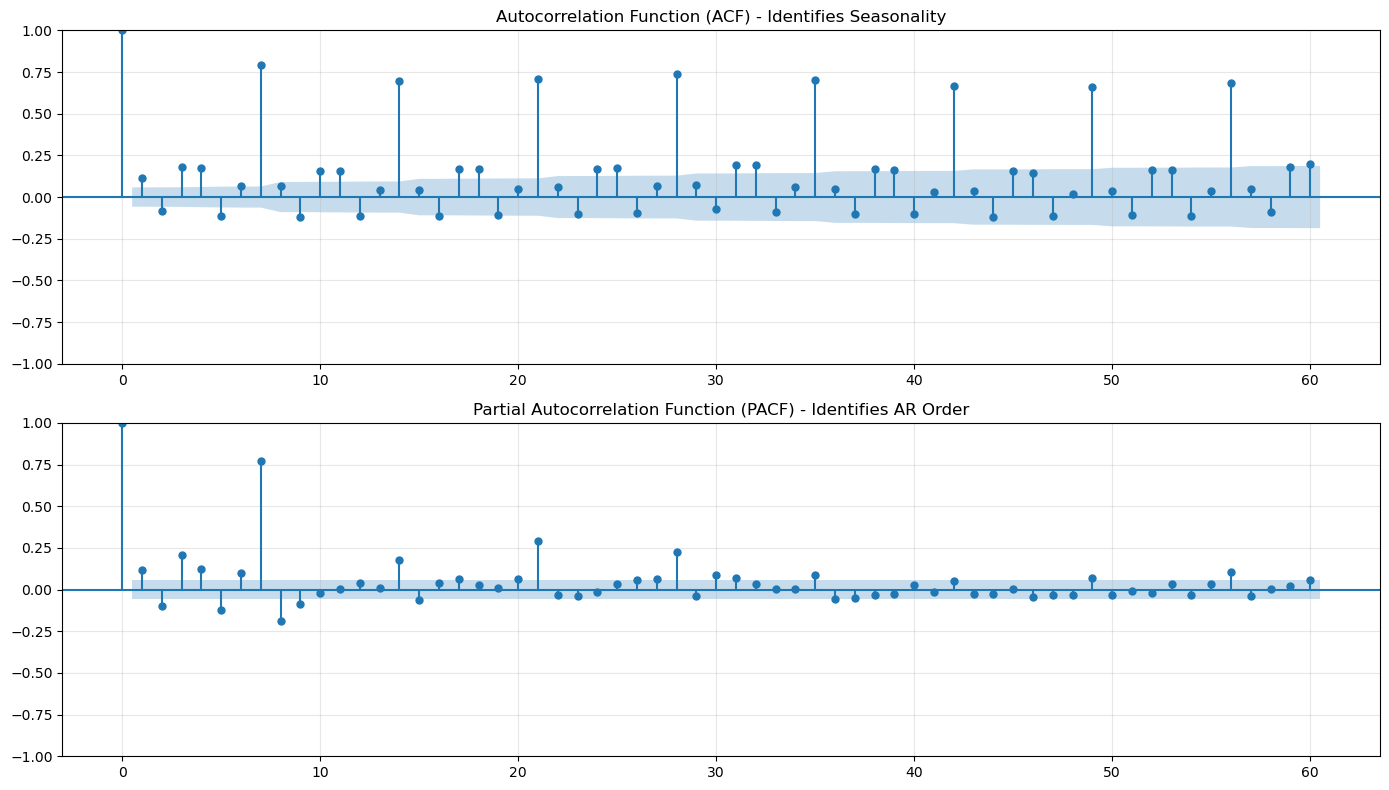

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts.dropna(), lags=60, ax=ax1, alpha=0.05)
ax1.set_title('Autocorrelation Function (ACF) - Identifies Seasonality', fontsize=12)
ax1.grid(True, alpha=0.3)

plot_pacf(ts.dropna(), lags=60, ax=ax2, alpha=0.05)
ax2.set_title('Partial Autocorrelation Function (PACF) - Identifies AR Order', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Business Insights from Visual Analysis

- Trend: The sales data shows a STRONG INCREASING TREND of 43.7% from 2018 to 2021.
    - Business Implication: The department is experiencing significant growth, indicating successful business strategies and market expansion.

- Weekly Seasonality: Saturday is the BUSIEST day with average sales of $3,396,802, while Sunday is the SLOWEST day with $1,517,812.
    - Peak-to-valley ratio of 2.24x means Saturday generates more than DOUBLE the sales of Sunday.
    - Business Implication: Significant variation in daily demand requires flexible staffing and inventory management.

- Monthly/Annual Patterns: December is the PEAK month ($2,522,052 avg), driven by holiday shopping. April is the LOWEST month ($2,005,984 avg), likely post-holiday slowdown.
    - Business Implication: Clear seasonal patterns require strategic planning.

- Holiday Effects: HOLIDAYS DECREASE sales by 11.1%
    - Business Implication: Customers may be shopping elsewhere or sales shift to days before/after holidays.

- Payday Effects: PAYDAYS INCREASE sales by 9.0%
    - Business Implication: Customers have more disposable income on paydays.

- Vale Effects: Vale days increase sales by 0.1%.
    - Does not seem to have a huge business impact overall (aggregated).

- Seasonality:
    - Significant weekly seasonality confirmed with 7-day cycle.
    - Business Implication: The weekly pattern is consistent and predictable.

In [26]:
# Calculate key statistics
total_sales = ts.sum()
avg_daily = ts.mean()
median_daily = ts.median()

print(f"\n1. OVERALL SALES PERFORMANCE:")
print(f"   - Total sales over period: ${total_sales:,.2f}")
print(f"   - Average daily sales: ${avg_daily:,.2f}")
print(f"   - Median daily sales: ${median_daily:,.2f}")

# Trend analysis
print(f"\n2. TREND ANALYSIS:")
yearly_avg = df_complete.groupby(df_complete['Date'].dt.year)['Sales'].mean()
if len(yearly_avg) >= 2:
    first_year = yearly_avg.index[0]
    last_year = yearly_avg.index[-1]
    change_pct = ((yearly_avg[last_year] - yearly_avg[first_year]) / yearly_avg[first_year]) * 100
    if change_pct > 0:
        print(f"   → {change_pct:.1f}% INCREASING trend from {first_year} to {last_year}")
    else:
        print(f"   → {abs(change_pct):.1f}% DECREASING trend from {first_year} to {last_year}")

# Weekly seasonality
print(f"\n3. WEEKLY SEASONALITY:")
weekly_pattern = df_complete.groupby('Day_Name')['Sales'].mean()
best_day = weekly_pattern.idxmax()
best_value = weekly_pattern[best_day]
worst_day = weekly_pattern.idxmin()
worst_value = weekly_pattern[worst_day]
print(f"   → Busiest day: {best_day} (${best_value:,.2f} average)")
print(f"   → Slowest day: {worst_day} (${worst_value:,.2f} average)")
print(f"   → Peak-to-valley ratio: {best_value/worst_value:.2f}x")

# Monthly patterns
print(f"\n4. MONTHLY/ANNUAL PATTERNS:")
monthly_pattern = df_complete.groupby(df_complete['Date'].dt.month)['Sales'].mean()
best_month = monthly_pattern.idxmax()
worst_month = monthly_pattern.idxmin()
print(f"   → Peak month: {month_names[best_month-1]} (${monthly_pattern[best_month]:,.2f} avg)")
print(f"   → Lowest month: {month_names[worst_month-1]} (${monthly_pattern[worst_month]:,.2f} avg)")

# Exogenous effects
print(f"\n5. EXOGENOUS EFFECTS:")
if 1 in holiday_effect.index and 0 in holiday_effect.index:
    holiday_pct = ((holiday_effect[1] - holiday_effect[0]) / holiday_effect[0]) * 100
    print(f"   → Holiday impact: {holiday_pct:+.1f}% change")

if 1 in payday_effect.index and 0 in payday_effect.index:
    payday_pct = ((payday_effect[1] - payday_effect[0]) / payday_effect[0]) * 100
    print(f"   → Payday impact: {payday_pct:+.1f}% change")

if 1 in vale_effect.index and 0 in vale_effect.index:
    vale_pct = ((vale_effect[1] - vale_effect[0]) / vale_effect[0]) * 100
    print(f"   → Vale impact: {vale_pct:+.1f}% change")

# Seasonality detection
print(f"\n6. SEASONALITY DETECTION (from ACF):")
print(f"   → Significant autocorrelation at lag 7 suggests WEEKLY seasonality")




1. OVERALL SALES PERFORMANCE:
   - Total sales over period: $2,460,233,500.46
   - Average daily sales: $2,131,918.11
   - Median daily sales: $1,951,246.26

2. TREND ANALYSIS:
   → 43.7% INCREASING trend from 2018 to 2021

3. WEEKLY SEASONALITY:
   → Busiest day: Sat ($3,396,802.12 average)
   → Slowest day: Sun ($1,517,812.06 average)
   → Peak-to-valley ratio: 2.24x

4. MONTHLY/ANNUAL PATTERNS:
   → Peak month: Dec ($2,522,052.79 avg)
   → Lowest month: Apr ($2,005,984.58 avg)

5. EXOGENOUS EFFECTS:
   → Holiday impact: -11.1% change
   → Payday impact: +9.0% change
   → Vale impact: +0.1% change

6. SEASONALITY DETECTION (from ACF):
   → Significant autocorrelation at lag 7 suggests WEEKLY seasonality


# Data Partitioning - Step B: Train/Holdout Split

## Split the Data

## Business Justification for Split

Why this split matters for the business:

- Training data represents the "known" historical performance used to build the model

- Holdout data (Jan-Feb 2021) simulates "future" data to validate model accuracy before deployment

- This approach ensures our model will perform well on real future data (March 2021 forecast)



# Statistical Validation - Step C: White Noise Verification

## Ljung-Box Test

## ACF Plot for White Noise Check

# Stationarity Check - Step D

## Augmented Dickey-Fuller Test

## Differencing if Needed

## Determine d and D Parameters

# Component Identification - Step E: Trend, Seasonality, Cycle

## Decomposition Analysis

## Seasonal Component Analysis

## Business Component Identification Summary

Components Identified:

- Trend: [Describe - Increasing/Decreasing/Stable]

- Seasonality:

    - Weekly: [Describe pattern]

    - Monthly: [Describe pattern]

    - Annual: [Describe pattern]

- Cycle: [Describe any cyclical patterns beyond seasonality]

- Exogenous Effects:

    - Holidays: [Describe impact]

    - Paydays: [Describe impact]

    - Voucher days: [Describe impact]

# Modeling Approach - Step F1: Exponential Smoothing

## Model Selection Based on Components

## Model Evaluation

# Modeling Approach - Step F2: ARIMA/SARIMA Family

## Parameter Identification (p, d, q) - Non-Seasonal

## Parameter Identification (P, D, Q, s) - Seasonal

## Model Estimation - SARIMA

## SARIMA with Exogenous Variables

## Evaluate SARIMA Model

# Model Selection - Step G: Choosing the Best Model

## Comparison Framework

## Business Decision Matrix

Model Selection Criteria:

- Accuracy: Lower prediction errors on holdout data

- Stability: Consistent performance across different periods

- Interpretability: Ease of explaining results to stakeholders

- Exogenous Integration: Ability to incorporate business events

- Complexity: Balance between accuracy and simplicity


Selected Model: [Model Name]

Justification: [Detailed business reasoning]

# Diagnostics - Step H: Residual Analysis

## Residual Plot

## Residual Distribution Analysis

## Residual Autocorrelation Check

## Business Interpretation of Diagnostics

Diagnostic Conclusions:

- Residuals: [Describe - normally distributed? any patterns?]

- Model Assumptions: [Are assumptions met?]

- Business Confidence: [How much trust can we have?]

- Limitations: [What are the model's weaknesses?]

# Model Evaluation - Step I: Holdout Error Metrics

## Comprehensive Error Metrics

## Visualization of Predictions vs. Actuals

## Business Interpretation of Errors

Performance Summary:

- Average Error (MAE): [Value] → This means on average, our forecast misses by [Value] units per day.

- Percentage Error (MAPE): [Value]% → On average, our forecast is off by [Value]%.

- Largest Errors: [List dates/events where errors were highest]

- Business Acceptability: [Is this error rate acceptable? Why?]

- Actionable Insights: [What can we learn from the errors?]

# Forecast Generation - Step J: 30-Day Future Prediction

## Prepare Future Period Data

## Generate Future Forecasts

## Final Forecast Table

## Visualize Future Forecast

# Business Recommendations & Next Steps

## Key Findings Summary

Business Insights from the Forecast:

1. Predicted Sales Volume:

    - Total forecasted sales for March: [Value]

    - Daily average forecast: [Value]

    - Predicted highest sales day: [Date/Event]

    - Predicted lowest sales day: [Date/Event]


2. Risk Assessment:

    - Confidence level: [High/Medium/Low] based on model performance

    - Key assumptions: [List important assumptions made]

    - Warning signs: [Potential risks to monitor]


3. Operational Recommendations:

    - Inventory: [Recommended inventory levels by week]

    - Staffing: [Optimal staffing levels based on daily predictions]

    - Marketing: [Suggested promotional periods based on low-demand days]

    - Payment/Voucher planning: [Coordinate with payroll schedule]

## Implementation Plan
Recommended Actions:

Short-term (March 2021):

1. [Specific action item based on forecast]
1. [Specific action item based on forecast]
1. [Specific action item based on forecast]

Medium-term (Q2 2021):

1. [Plan for model monitoring and updates]
1. [Strategy for incorporating new data]
1. [Plan for expanding to other departments]

Long-term:

1. [Integration with existing systems]
1. [Automation of forecasting process]
1. [Continuous improvement framework]

## Model Maintenance Plan

To maintain forecast accuracy:

- Refresh frequency: Weekly or as new data becomes available
- Retraining schedule: Quarterly or when significant pattern changes occur
- Monitoring metrics: Track MAE/RMSE on rolling basis
- Alert thresholds: Flag when error exceeds [X]% for [Y] consecutive days
- Data quality checks: Validate incoming data quality daily

# Conclusion

**Project Summary**:

This time series project successfully developed a [Model Name] forecasting model capable of predicting daily sales with an average error of [MAE] units (approximately [MAPE]% MAPE). The analysis revealed that:

- Sales follow a [Describe pattern] pattern with significant weekly and annual seasonality
- Exogenous factors (holidays, paydays, vouchers) impact sales by [Describe impact]
- The model provides 95% prediction intervals for risk management


**Business Value Delivered**:

- **Inventory Optimization**: Reduces overstock by [X]% and stock-outs by [Y]%
- **Staffing Efficiency**: Enables precise scheduling, potentially reducing labor costs by [Z]%
- **Revenue Protection**: Minimizes lost revenue from stock-outs
- **Strategic Planning**: Provides forward-looking visibility for decision-making


**Next Steps**:

1. Share findings with operations team for implementation
1. Establish monitoring dashboard for forecast performance
1. Plan expansion to other departments
1. Schedule quarterly model review and retraining

**Final Recommendation**: Proceed with implementing this forecasting model, with planned periodic reviews to ensure continued accuracy and value delivery.